In [1]:
from helpers import *
import numpy as np
from pandas import DataFrame, concat
import pandas as pd
from IPython.display import display, Markdown

In [2]:
spatial = pd.read_excel(
    "local_data3.xlsx"
)


In [3]:
spatial2 = spatial.drop(columns=["TOP3_업종", "기타_비율", "위도", "경도", "만명당_가맹점수", "서울중심지_거리_km", "과학·기술_비율", "시설관리·임대_비율", "교육_비율", "보건의료_비율", "예술·스포츠_비율", "수리·개인_비율", "소매_비율", "숙박_비율", "음식_비율", "부동산_비율", "평균매출", "1인당_유동인구", "1인당_유동인구", "전체가맹점수", "총_가맹점수"])

In [4]:
spatial2.to_excel("local_data4.xlsx", index=False)

In [5]:
spatial2.head()

,행정동코드,행정구역,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,spatial_cluster
0,4111156000,경기도 수원시 장안구 파장동,24479.416667,2.465431e+05,263.333333,2.333333,238.000000,1.000000,6.666667,3.666667,29.666667,21.000000,22.666667,89.333333,20.000000,0
1,4111156600,경기도 수원시 장안구 율천동,40142.208333,5.287070e+05,239.666667,2.666667,446.666667,2.666667,8.000000,4.333333,116.000000,28.333333,68.666667,161.000000,31.333333,2
2,4111157100,경기도 수원시 장안구 정자1동,31046.958333,3.570282e+05,126.000000,2.000000,117.000000,0.000000,3.333333,0.666667,80.666667,17.666667,15.333333,57.000000,13.000000,2
3,4111157200,경기도 수원시 장안구 정자2동,37978.750000,1.329960e+06,252.666667,4.666667,235.333333,1.000000,5.000000,1.666667,49.000000,23.000000,21.666667,129.000000,23.000000,2
4,4111157300,경기도 수원시 장안구 정자3동,39261.500000,6.991828e+05,249.666667,0.000000,304.000000,1.666667,11.000000,7.000000,229.666667,44.666667,53.333333,124.000000,19.666667,2


In [6]:
origin = pd.read_csv(
    "지역화폐_월별_업종대분류.csv", encoding="utf-8-sig"
)


In [7]:
origin = origin.merge(
    spatial2[["행정동코드", "spatial_cluster"]],
    on="행정동코드",
    how="left",
    validate="many_to_one"
)

In [8]:
origin["기준년월"] = origin["기준년월"].astype(str).str[-2:]
origin = origin.rename(columns={"기준년월": "기준월"})

In [9]:
origin.head()

,기준월,행정동코드,매출금액,활성화비율,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,spatial_cluster
0,07,4111156000,41128684.0,100.0,경기도 수원시 장안구 파장동,22480.0,241011.94,2023,274,3,248,1,6,4,14,21,25,97,19,0
1,08,4111156000,5115679.0,100.0,경기도 수원시 장안구 파장동,22451.0,241268.02,2023,274,3,248,1,6,4,14,21,25,97,19,0
2,09,4111156000,436318.0,100.0,경기도 수원시 장안구 파장동,22410.0,236580.40,2023,274,3,248,1,6,4,14,21,25,97,19,0
3,10,4111156000,631469.0,100.0,경기도 수원시 장안구 파장동,23628.0,268762.16,2023,274,3,248,1,6,4,14,21,25,97,19,0
4,11,4111156000,591386.0,100.0,경기도 수원시 장안구 파장동,24542.0,253510.66,2023,274,3,248,1,6,4,14,21,25,97,19,0


In [10]:
origin = origin.drop(columns=["활성화비율"])

In [11]:
origin.to_excel("local_dataset.xlsx", index=False)

In [12]:
df1 = my_qtcheck.set_type(origin, as_category=["spatial_cluster", "년도", "기준월"])

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   기준월              6240 non-null   category
 1   행정동코드            6240 non-null   int64   
 2   매출금액             6240 non-null   float64 
 3   행정구역             6240 non-null   str     
 4   총인구수             6240 non-null   float64 
 5   월유동인구수           6240 non-null   float64 
 6   년도               6240 non-null   category
 7   가맹점수_소매          6240 non-null   int64   
 8   가맹점수_숙박          6240 non-null   int64   
 9   가맹점수_음식          6240 non-null   int64   
 10  가맹점수_부동산         6240 non-null   int64   
 11  가맹점수_과학·기술       6240 non-null   int64   
 12  가맹점수_시설관리·임대     6240 non-null   int64   
 13  가맹점수_교육          6240 non-null   int64   
 14  가맹점수_보건의료        6240 non-null   int64   
 15  가맹점수_예술·스포츠      6240 non-null   int64   
 16  가맹점수_수리·개인       6240 non-null   int64   
 17  가맹점수_기

In [13]:
# 중복값 제거
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 0


,기준월,행정동코드,매출금액,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,spatial_cluster
0,07,4111156000,41128684.0,경기도 수원시 장안구 파장동,22480.0,241011.94,2023,274,3,248,1,6,4,14,21,25,97,19,0
1,08,4111156000,5115679.0,경기도 수원시 장안구 파장동,22451.0,241268.02,2023,274,3,248,1,6,4,14,21,25,97,19,0
2,09,4111156000,436318.0,경기도 수원시 장안구 파장동,22410.0,236580.40,2023,274,3,248,1,6,4,14,21,25,97,19,0
3,10,4111156000,631469.0,경기도 수원시 장안구 파장동,23628.0,268762.16,2023,274,3,248,1,6,4,14,21,25,97,19,0
4,11,4111156000,591386.0,경기도 수원시 장안구 파장동,24542.0,253510.66,2023,274,3,248,1,6,4,14,21,25,97,19,0


In [14]:
# 결측치 비율 확인
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
기준월,0,0.0
행정동코드,0,0.0
매출금액,0,0.0
행정구역,0,0.0
총인구수,0,0.0
월유동인구수,0,0.0
년도,0,0.0
가맹점수_소매,0,0.0
가맹점수_숙박,0,0.0
가맹점수_음식,0,0.0


In [15]:
df2_categorical_qtcheck = my_qtcheck.categorical_summary(df2, save_path=None)
df2_numerical_qtcheck = my_qtcheck.numerical_summary(df2, save_path=None)

📊 컬럼 '기준월'의 value_counts():


,count
기준월,
01,520
02,520
03,520
04,520
05,520
06,520
07,520
08,520
09,520


📊 컬럼 '년도'의 value_counts():


,count
년도,
2023,1560
2024,3120
2025,1560


📊 컬럼 'spatial_cluster'의 value_counts():


,count
spatial_cluster,
0,2544
1,1632
2,2064


In [16]:
display(df2)
display(df2_categorical_qtcheck)
display(df2_numerical_qtcheck.T)

,기준월,행정동코드,매출금액,행정구역,총인구수,월유동인구수,년도,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타,spatial_cluster
0,07,4111156000,41128684.0,경기도 수원시 장안구 파장동,22480.0,241011.94,2023,274,3,248,1,6,4,14,21,25,97,19,0
1,08,4111156000,5115679.0,경기도 수원시 장안구 파장동,22451.0,241268.02,2023,274,3,248,1,6,4,14,21,25,97,19,0
2,09,4111156000,436318.0,경기도 수원시 장안구 파장동,22410.0,236580.40,2023,274,3,248,1,6,4,14,21,25,97,19,0
3,10,4111156000,631469.0,경기도 수원시 장안구 파장동,23628.0,268762.16,2023,274,3,248,1,6,4,14,21,25,97,19,0
4,11,4111156000,591386.0,경기도 수원시 장안구 파장동,24542.0,253510.66,2023,274,3,248,1,6,4,14,21,25,97,19,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6235,02,4167053000,63164.0,경기도 여주시 오학동,18208.0,57216.81,2025,193,2,268,0,6,1,36,12,31,84,20,2
6236,03,4167053000,119778.0,경기도 여주시 오학동,18222.0,74042.89,2025,193,2,268,0,6,1,36,12,31,84,20,2
6237,04,4167053000,79864.0,경기도 여주시 오학동,18229.0,61845.05,2025,193,2,268,0,6,1,36,12,31,84,20,2
6238,05,4167053000,462451.0,경기도 여주시 오학동,18213.0,70867.16,2025,193,2,268,0,6,1,36,12,31,84,20,2


,기준월,년도,spatial_cluster
count,6240,6240,6240
unique,12,3,3
top,01,2024,0
freq,520,3120,2544


,행정동코드,매출금액,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타
count,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0,6240.0
mean,4131567895.384615,18829866.649038,26059.542468,468258.3433,209.217308,2.947115,255.900962,0.760577,9.325,2.758654,76.174038,24.150962,33.043269,98.939423,21.418269
std,15590848.095135,74064028.843516,12320.289688,557773.449512,135.586095,6.011377,180.953453,1.081122,9.267938,3.012783,68.417115,20.087849,24.4065,63.056567,15.802345
min,4111156000.0,386.0,978.0,511.86,6.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,4117358750.0,322422.75,17583.5,102517.29,121.0,0.0,133.75,0.0,3.0,1.0,28.0,9.0,15.0,55.0,11.0
50%,4128157000.0,846558.0,24476.0,286276.045,182.5,1.0,214.0,0.0,7.0,2.0,55.0,20.0,28.5,87.0,18.0
75%,4145334250.0,2145762.5,34141.5,593990.425,260.0,3.0,327.25,1.0,12.0,4.0,103.0,33.0,45.0,126.0,27.0
max,4167053000.0,892136990.0,69751.0,3405776.5,1176.0,57.0,1240.0,6.0,84.0,26.0,470.0,111.0,142.0,359.0,96.0
rel_diff,0.000826,21.242855,0.064698,0.635688,0.146396,1.947115,0.195799,inf,0.332143,0.379327,0.384983,0.207548,0.159413,0.137235,0.189904
rdiff_flag,similar,large_diff,similar,large_diff,diff,large_diff,diff,large_diff,diff,diff,diff,diff,diff,diff,diff


In [17]:
df2.to_excel("local_spatial_qtcheck.xlsx", index=False)
df2_categorical_qtcheck.to_excel("local_spatial_categorical_qtcheck.xlsx")
df2_numerical_qtcheck.to_excel("local_spatial_numerical_qtcheck.xlsx")

In [18]:
# 4. 변수 유형 분류
# 종속변수
target = "매출금액"
# 종속변수 연속형 여부
target_is_continuous = True

# 명목형 변수
nominal_cols = my_qtcheck.get_categorical_column_names(df2)
# 연속형 변수
continuous_cols = my_qtcheck.get_number_column_names(df2)

if target_is_continuous:
    # 연속형 변수 이름에서 종속변수 항목 제거
    continuous_cols.remove(target)
else:
    # 명목형 변수 이름에서 종속변수 항목 제거
    nominal_cols.remove(target)

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형 :", nominal_cols)
print("연속형 :", continuous_cols)

종속변수 : 매출금액
종속변수 유형: 연속형
명목형 : ['기준월', '년도', 'spatial_cluster']
연속형 : ['행정동코드', '총인구수', '월유동인구수', '가맹점수_소매', '가맹점수_숙박', '가맹점수_음식', '가맹점수_부동산', '가맹점수_과학·기술', '가맹점수_시설관리·임대', '가맹점수_교육', '가맹점수_보건의료', '가맹점수_예술·스포츠', '가맹점수_수리·개인', '가맹점수_기타']


In [19]:
# 품질 점검 완료 데이터 셋 가져오기
origin = pd.read_excel("local_spatial_qtcheck.xlsx")
num_desc = pd.read_excel("local_spatial_numerical_qtcheck.xlsx", index_col=0)
cat_desc = pd.read_excel("local_spatial_categorical_qtcheck.xlsx", index_col=0)

In [20]:
# 타입 변환(명목형 확정)
df3 = my_qtcheck.set_type(origin, as_category=cat_desc.columns)

<class 'pandas.DataFrame'>
RangeIndex: 6240 entries, 0 to 6239
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   기준월              6240 non-null   category
 1   행정동코드            6240 non-null   int64   
 2   매출금액             6240 non-null   int64   
 3   행정구역             6240 non-null   str     
 4   총인구수             6240 non-null   int64   
 5   월유동인구수           6240 non-null   float64 
 6   년도               6240 non-null   category
 7   가맹점수_소매          6240 non-null   int64   
 8   가맹점수_숙박          6240 non-null   int64   
 9   가맹점수_음식          6240 non-null   int64   
 10  가맹점수_부동산         6240 non-null   int64   
 11  가맹점수_과학·기술       6240 non-null   int64   
 12  가맹점수_시설관리·임대     6240 non-null   int64   
 13  가맹점수_교육          6240 non-null   int64   
 14  가맹점수_보건의료        6240 non-null   int64   
 15  가맹점수_예술·스포츠      6240 non-null   int64   
 16  가맹점수_수리·개인       6240 non-null   int64   
 17  가맹점수_기

In [21]:
column_means = {
    "기준월": "데이터 기준 월",
    "행정동코드": "행정동 식별 코드",
    "매출금액": "지역화폐 매출금액(원)",
    "행정구역": "행정구역명",
    "총인구수": "행정동 총인구수(명)",
    "월유동인구수": "행정동 월 유동인구수",
    "년도": "데이터 기준 연도",
    "가맹점수_소매": "소매업 수",
    "가맹점수_숙박": "숙박업 수",
    "가맹점수_음식": "음식업 수",
    "가맹점수_부동산": "부동산업 수",
    "가맹점수_과학·기술": "과학·기술업 수",
    "가맹점수_시설관리·임대": "시설관리·임대업 수",
    "가맹점수_교육": "교육 분야업 수",
    "가맹점수_보건의료": "보건의료 분야업 수",
    "가맹점수_예술·스포츠": "예술·스포츠업 수",
    "가맹점수_수리·개인": "수리·개인서비스업 수",
    "가맹점수_기타": "기타 업종 수",
    "spatial_cluster": "행정동 공간 군집"
}

In [22]:
# 종속변수 기술통계량 추출
num_desc.loc[[target]].T

,매출금액
count,6240
mean,18829866.649038
std,74064028.843516
min,386.0
25%,322422.75
50%,846558.0
75%,2145762.5
max,892136990.0
rel_diff,21.242855
rdiff_flag,large_diff


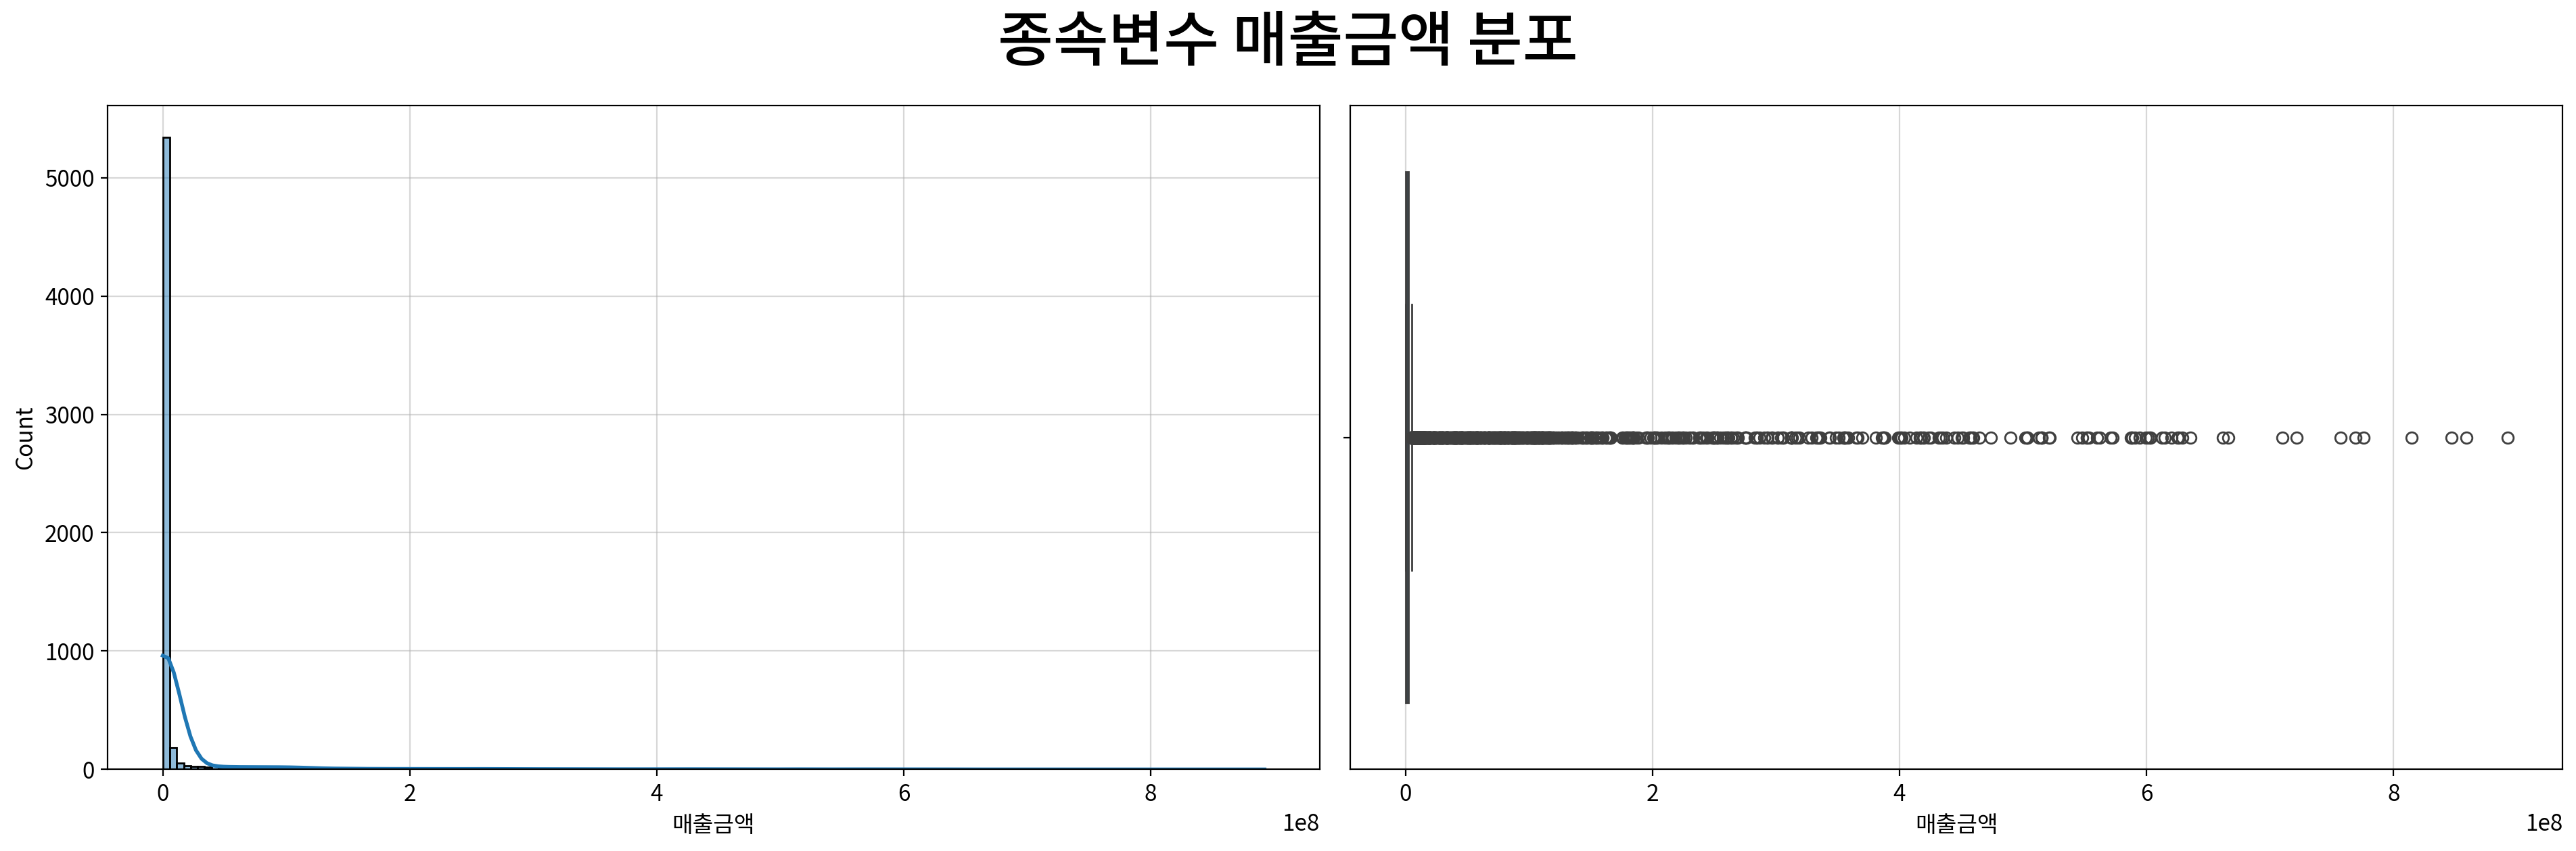

,매출금액
count,6240
mean,18829866.649038
std,74064028.843516
min,386.0
25%,322422.75
50%,846558.0
75%,2145762.5
max,892136990.0
rel_diff,21.242855
rdiff_flag,large_diff


In [23]:
# 02. 단변량 분석
# 1. 연속형 종속변수에 대한 단변량 분석
# 1행 2열 서브플롯 구성
# -> 그래프 크기는 서브플롯 중 하나의 크기(전체 크기는 가로 960 x 2가 됨)
fig, ax = my_plot.init(rows=1, cols=2,
                       title=f"종속변수 {target} 분포", width=960, height=640)
my_plot.histplot(data=df3, x=target, kde=True, ax=ax[0])
my_plot.boxplot(data=df3, x=target, ax=ax[1])
my_plot.show()

# 연속형 변수 기술통계량에서 종속변수에 대한 부분만 추출
num_desc[num_desc.index == target].T

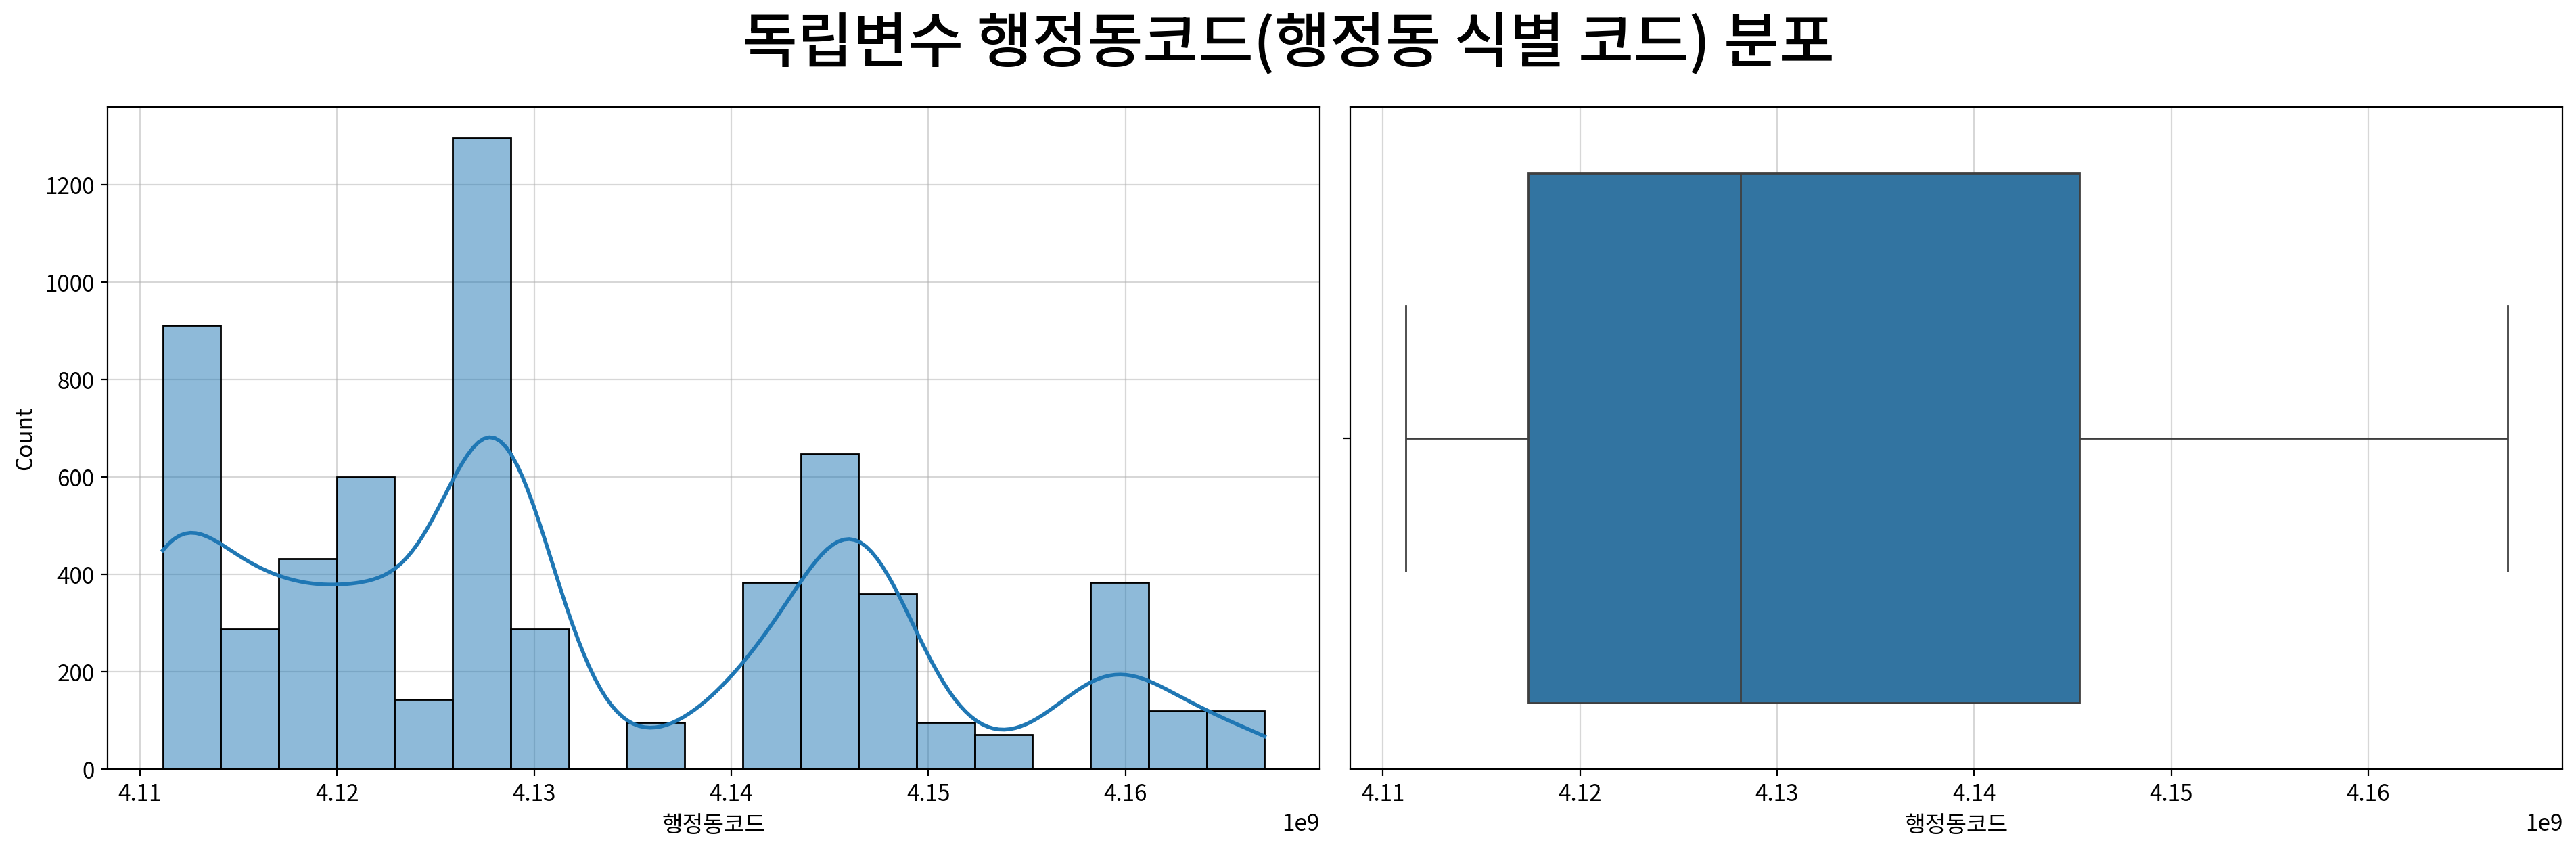

,행정동코드
count,6240
mean,4131567895.384615
std,15590848.095135
min,4111156000.0
25%,4117358750.0
50%,4128157000.0
75%,4145334250.0
max,4167053000.0
rel_diff,0.000826
rdiff_flag,similar


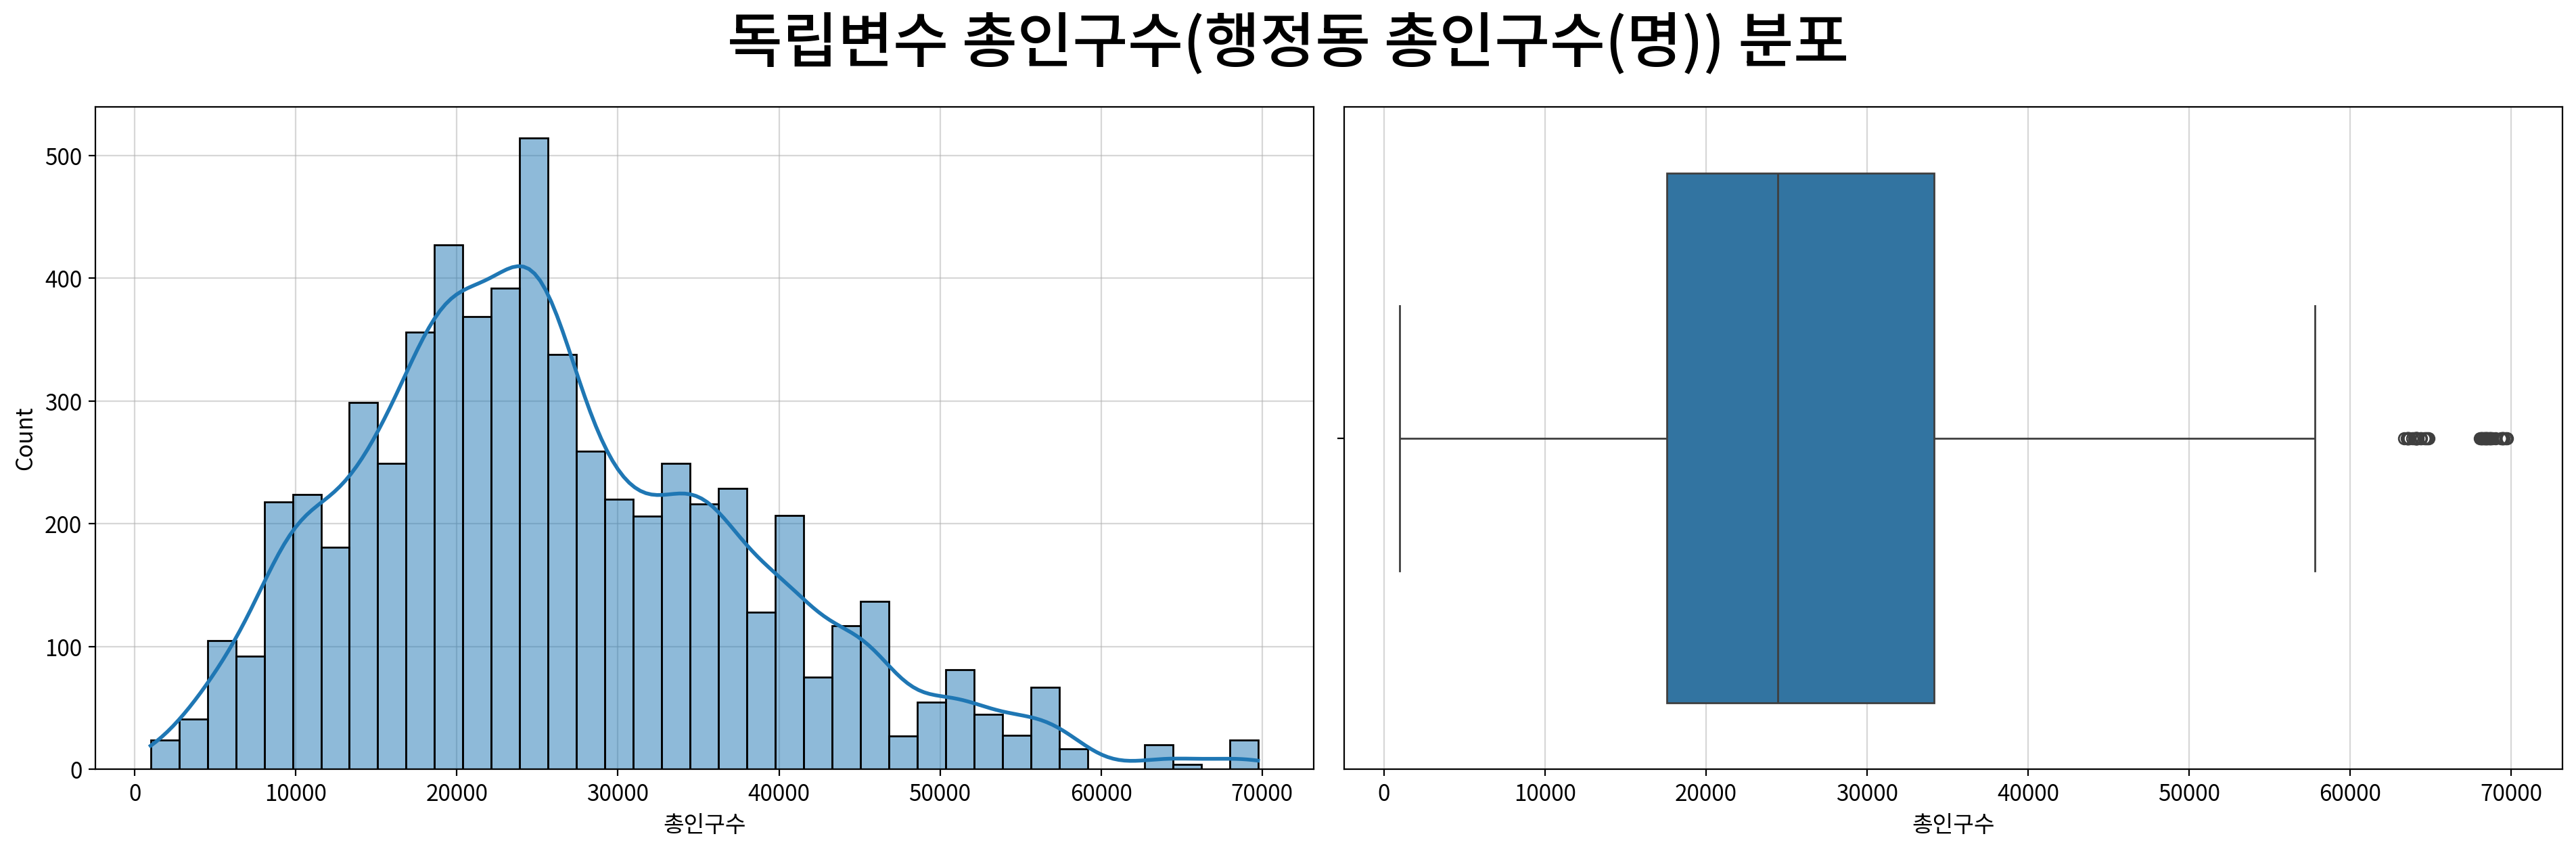

,총인구수
count,6240
mean,26059.542468
std,12320.289688
min,978.0
25%,17583.5
50%,24476.0
75%,34141.5
max,69751.0
rel_diff,0.064698
rdiff_flag,similar


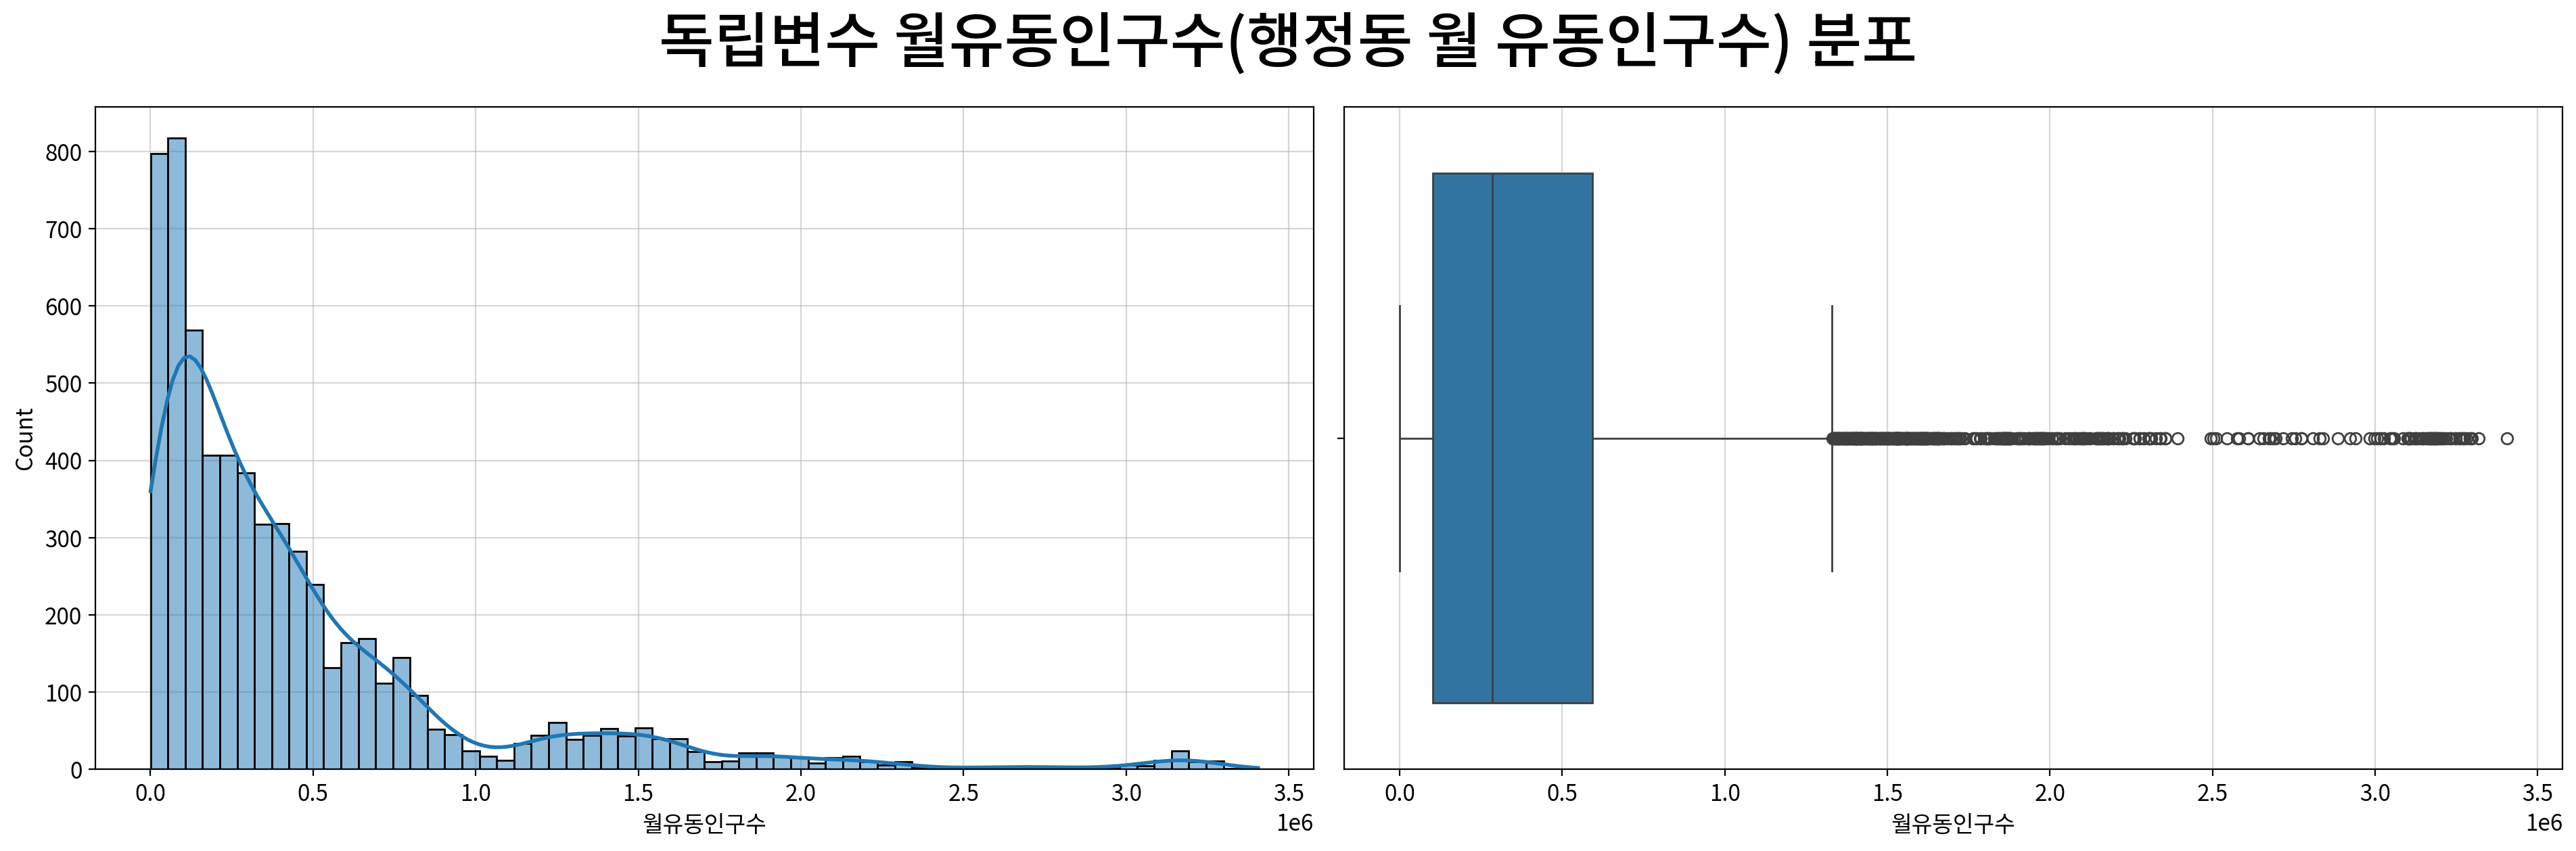

,월유동인구수
count,6240
mean,468258.3433
std,557773.449512
min,511.86
25%,102517.29
50%,286276.045
75%,593990.425
max,3405776.5
rel_diff,0.635688
rdiff_flag,large_diff


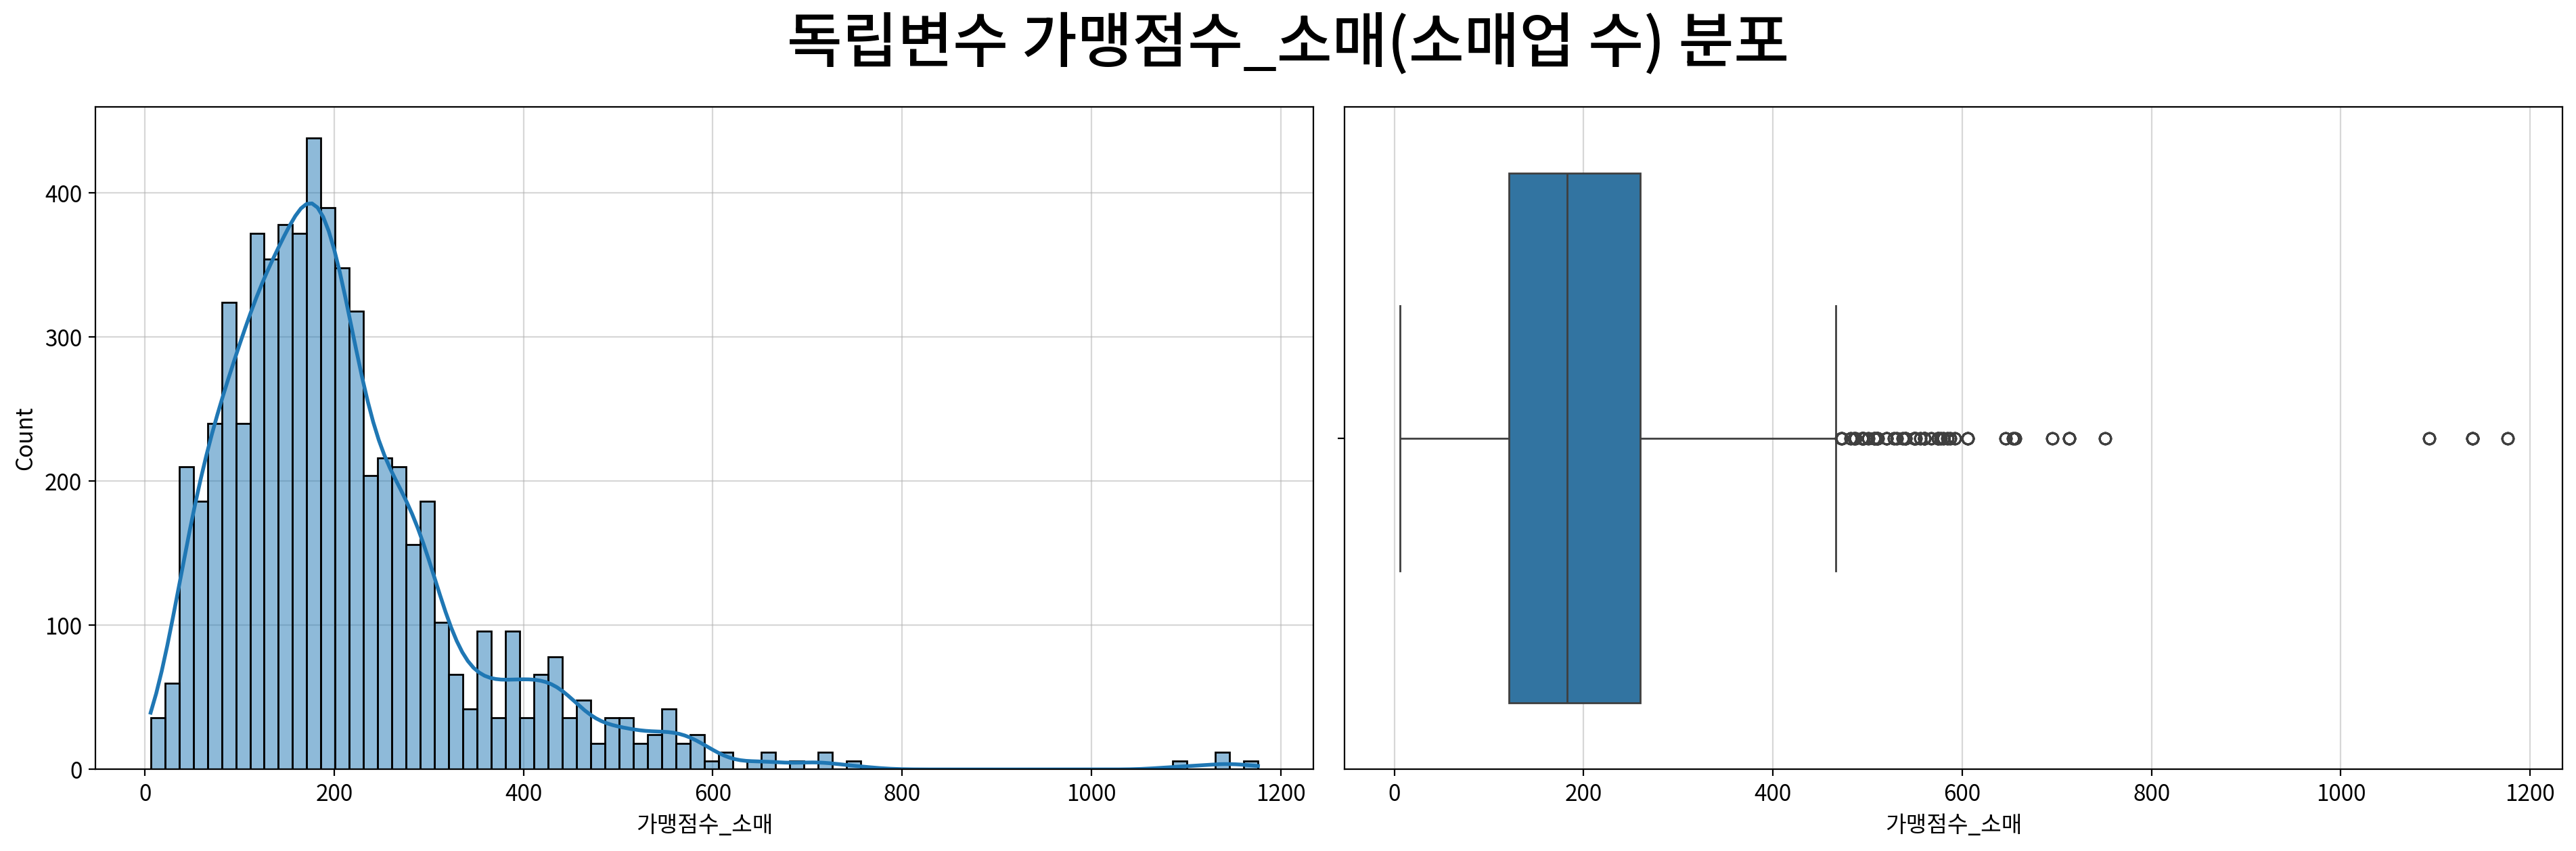

,가맹점수_소매
count,6240
mean,209.217308
std,135.586095
min,6.0
25%,121.0
50%,182.5
75%,260.0
max,1176.0
rel_diff,0.146396
rdiff_flag,diff


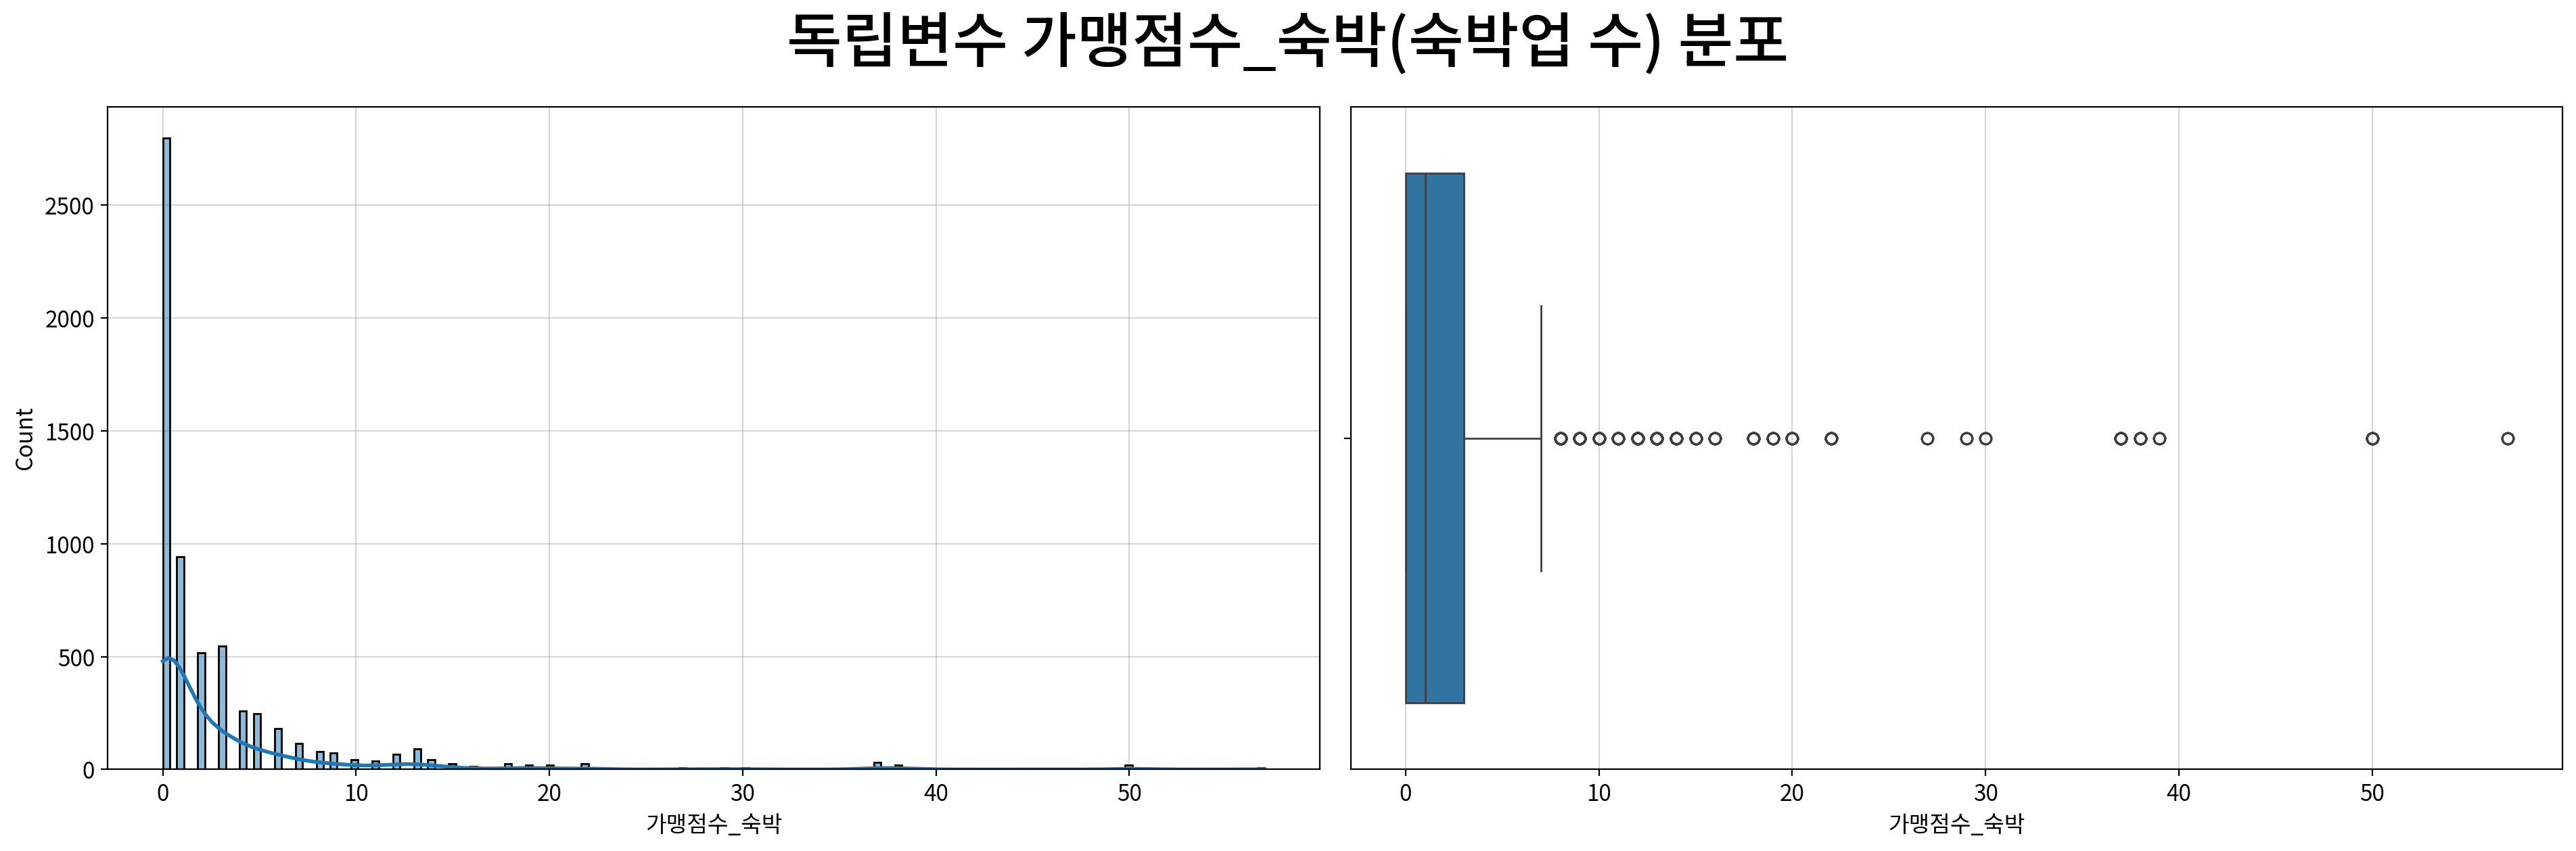

,가맹점수_숙박
count,6240
mean,2.947115
std,6.011377
min,0.0
25%,0.0
50%,1.0
75%,3.0
max,57.0
rel_diff,1.947115
rdiff_flag,large_diff


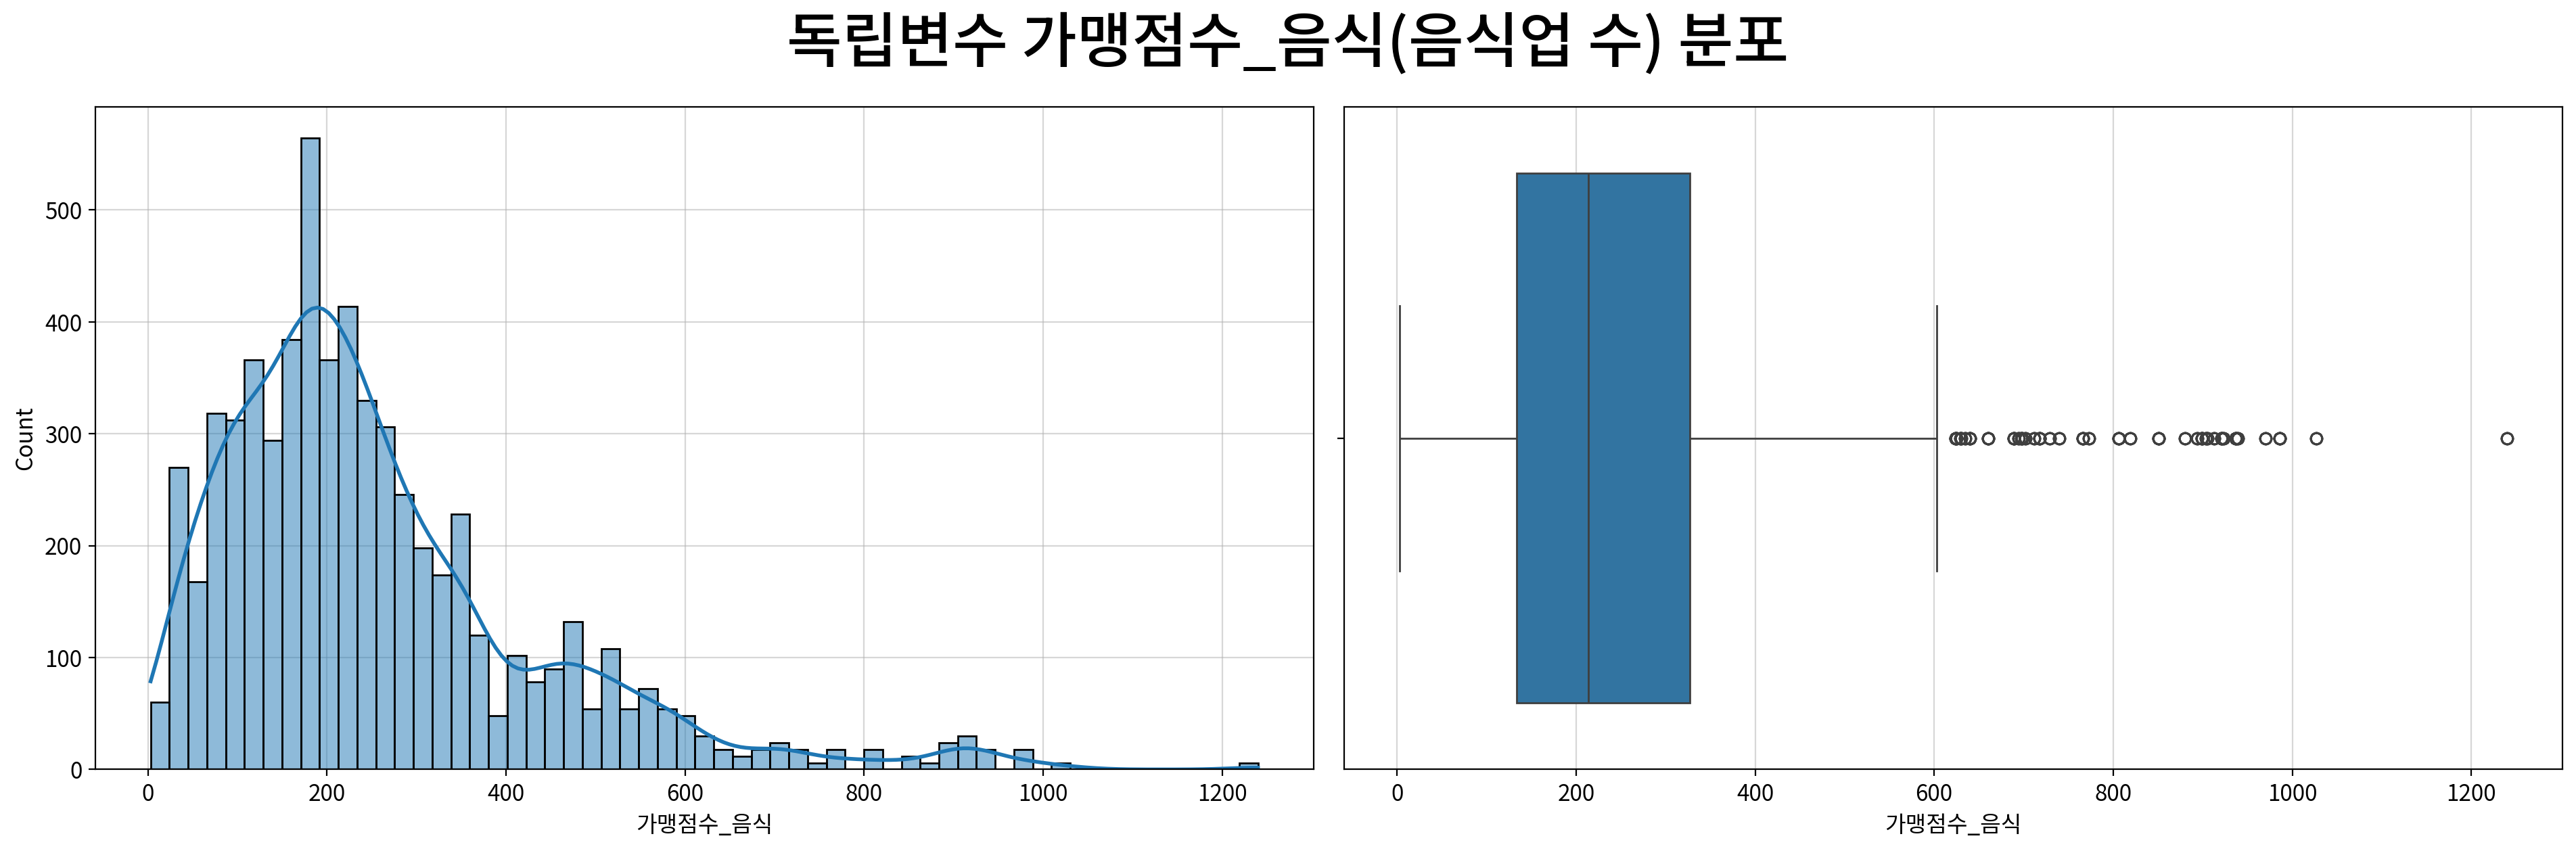

,가맹점수_음식
count,6240
mean,255.900962
std,180.953453
min,3.0
25%,133.75
50%,214.0
75%,327.25
max,1240.0
rel_diff,0.195799
rdiff_flag,diff


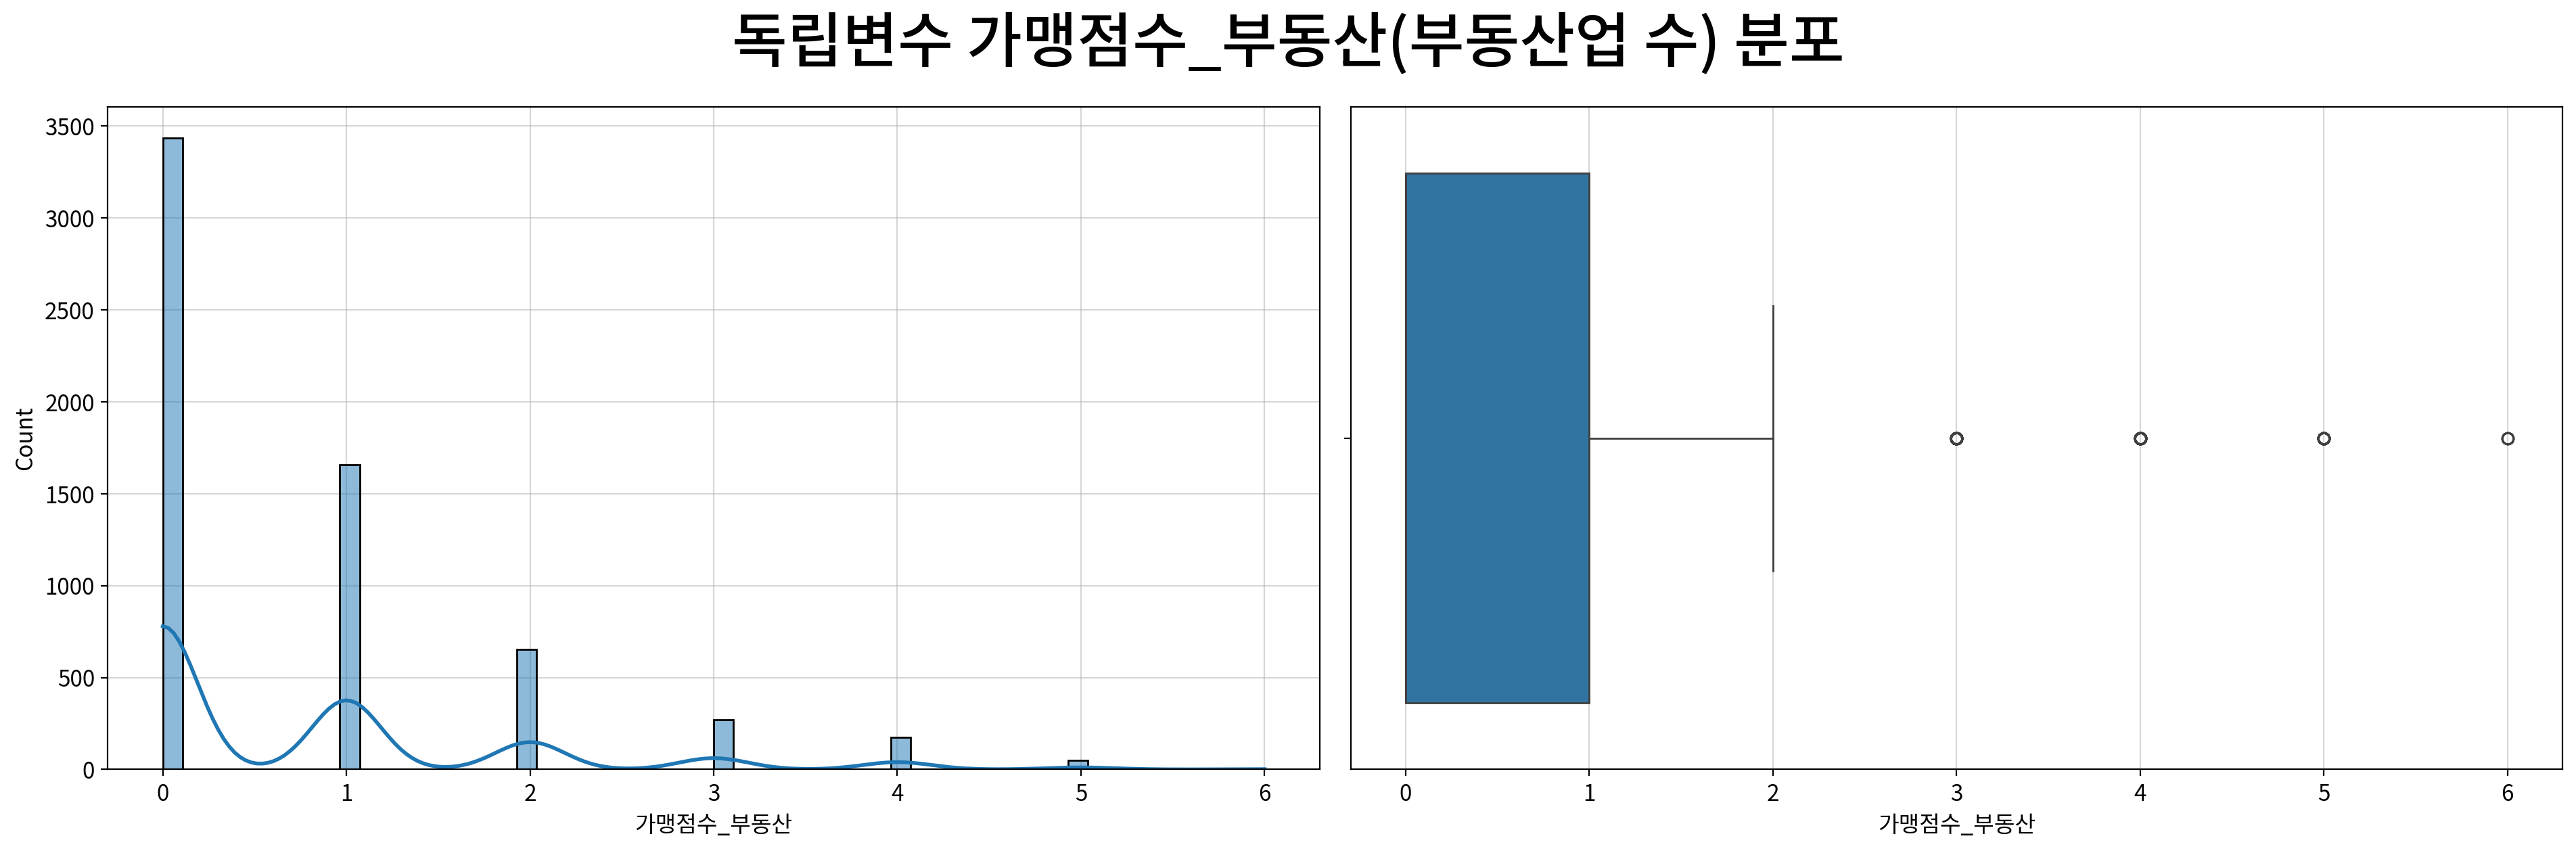

,가맹점수_부동산
count,6240
mean,0.760577
std,1.081122
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,6.0
rel_diff,inf
rdiff_flag,large_diff


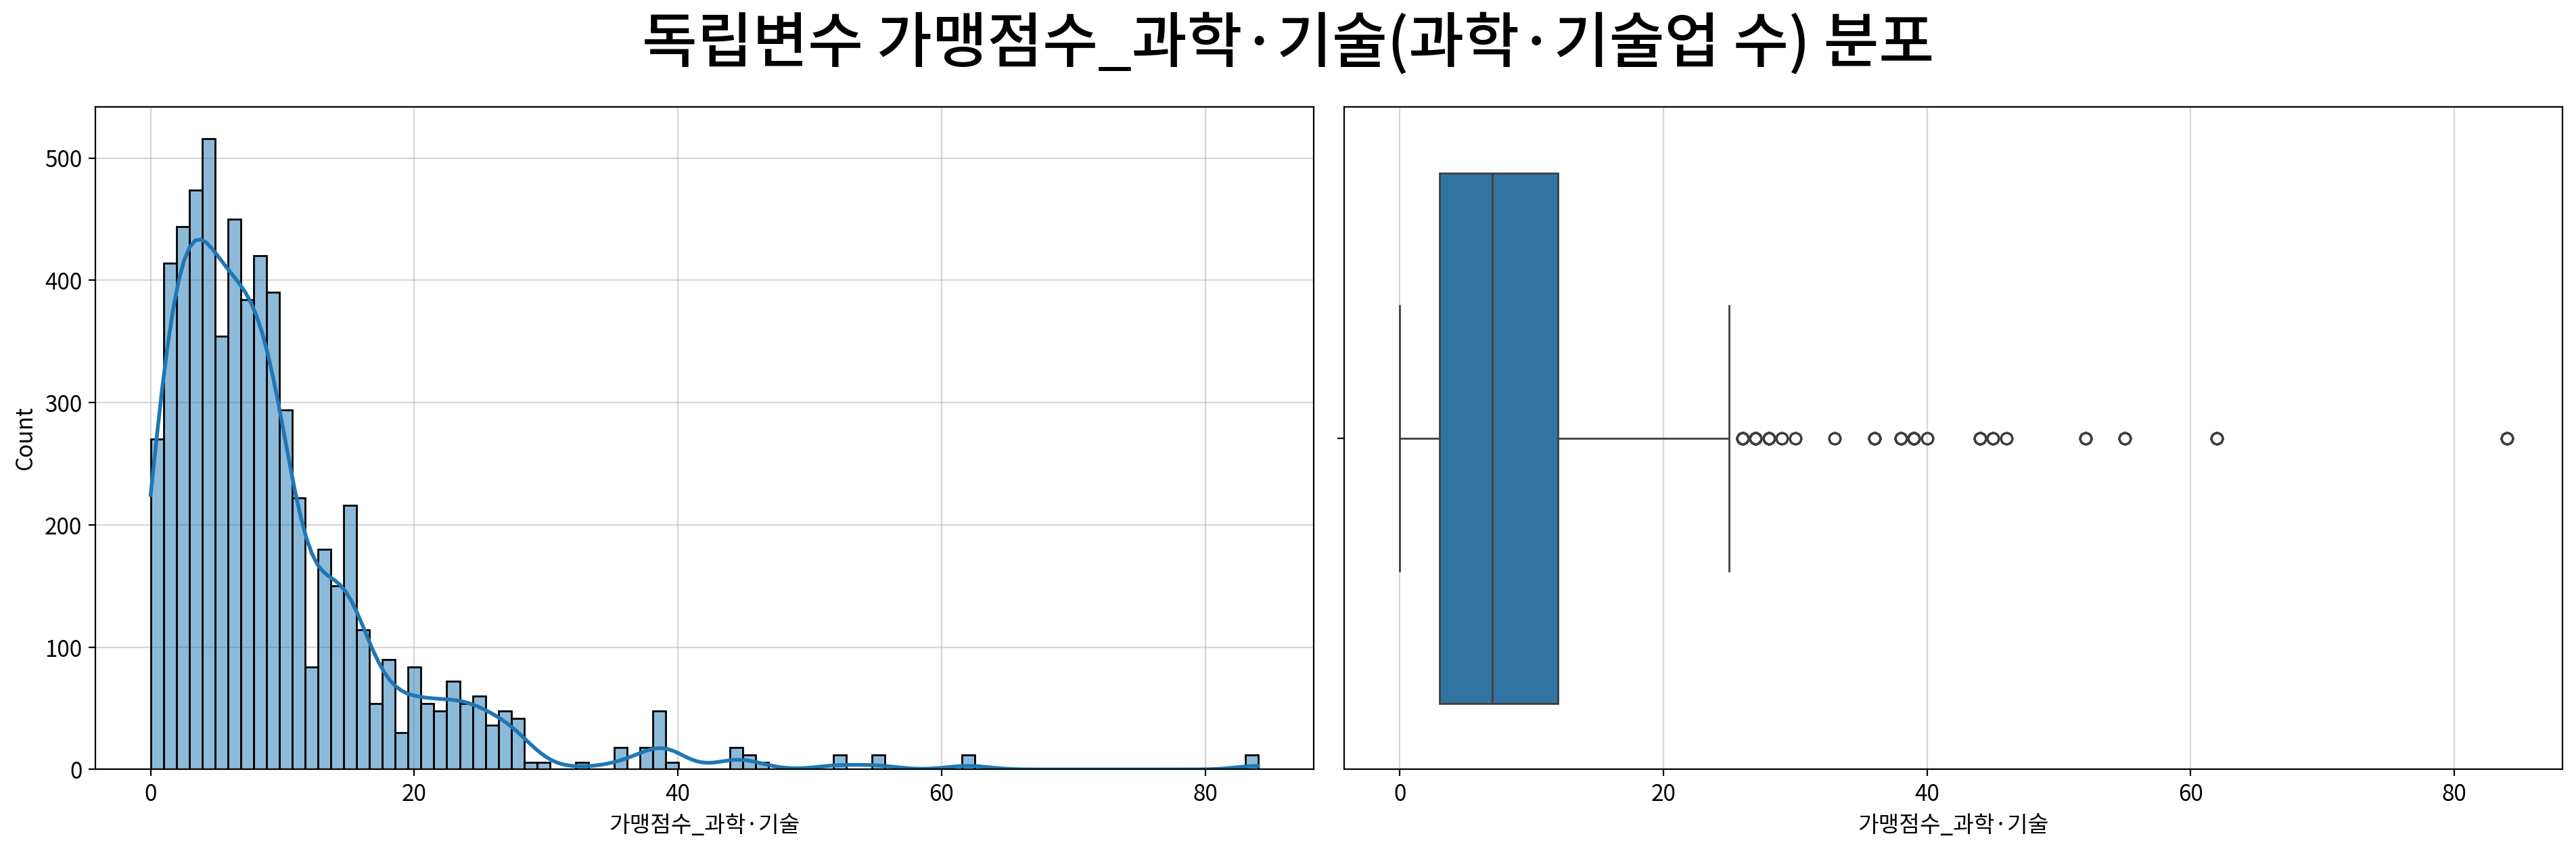

,가맹점수_과학·기술
count,6240
mean,9.325
std,9.267938
min,0.0
25%,3.0
50%,7.0
75%,12.0
max,84.0
rel_diff,0.332143
rdiff_flag,diff


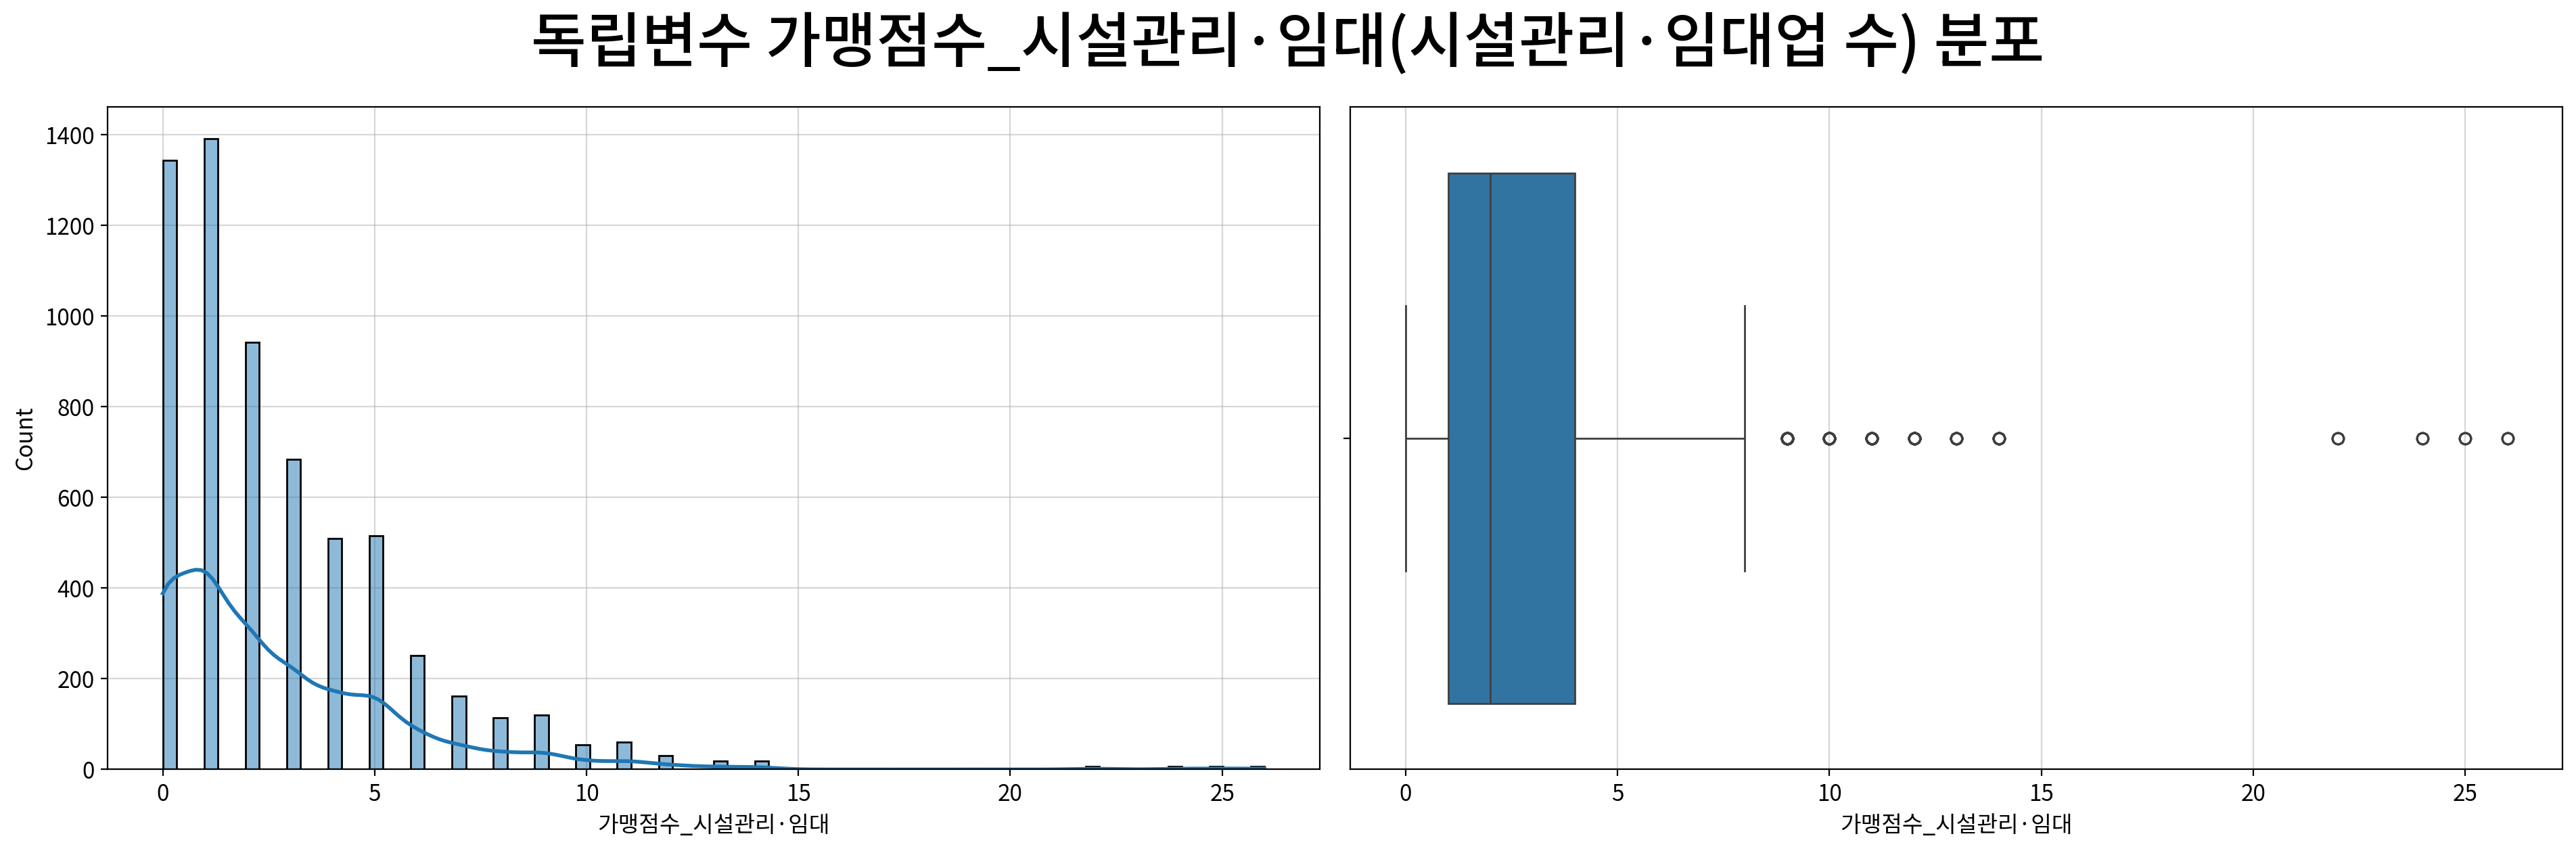

,가맹점수_시설관리·임대
count,6240
mean,2.758654
std,3.012783
min,0.0
25%,1.0
50%,2.0
75%,4.0
max,26.0
rel_diff,0.379327
rdiff_flag,diff


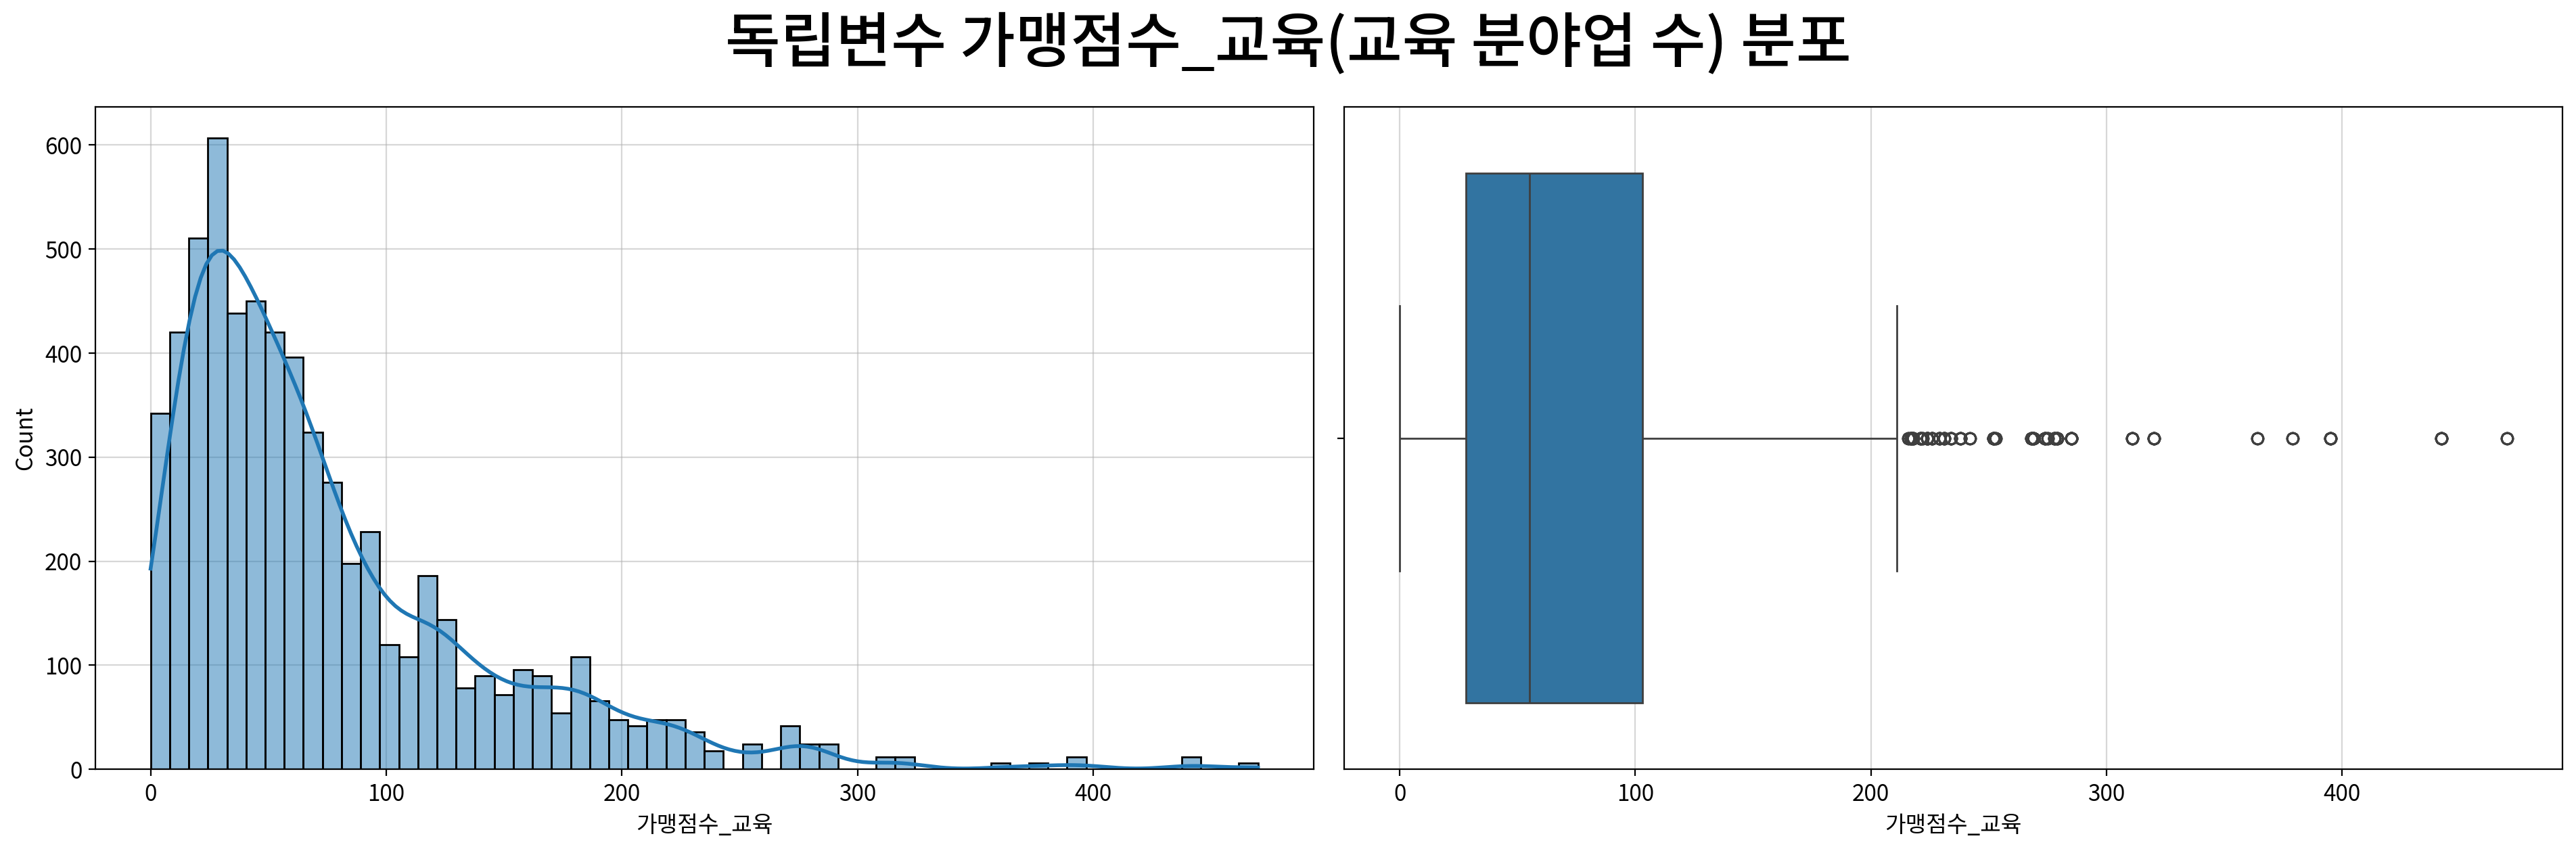

,가맹점수_교육
count,6240
mean,76.174038
std,68.417115
min,0.0
25%,28.0
50%,55.0
75%,103.0
max,470.0
rel_diff,0.384983
rdiff_flag,diff


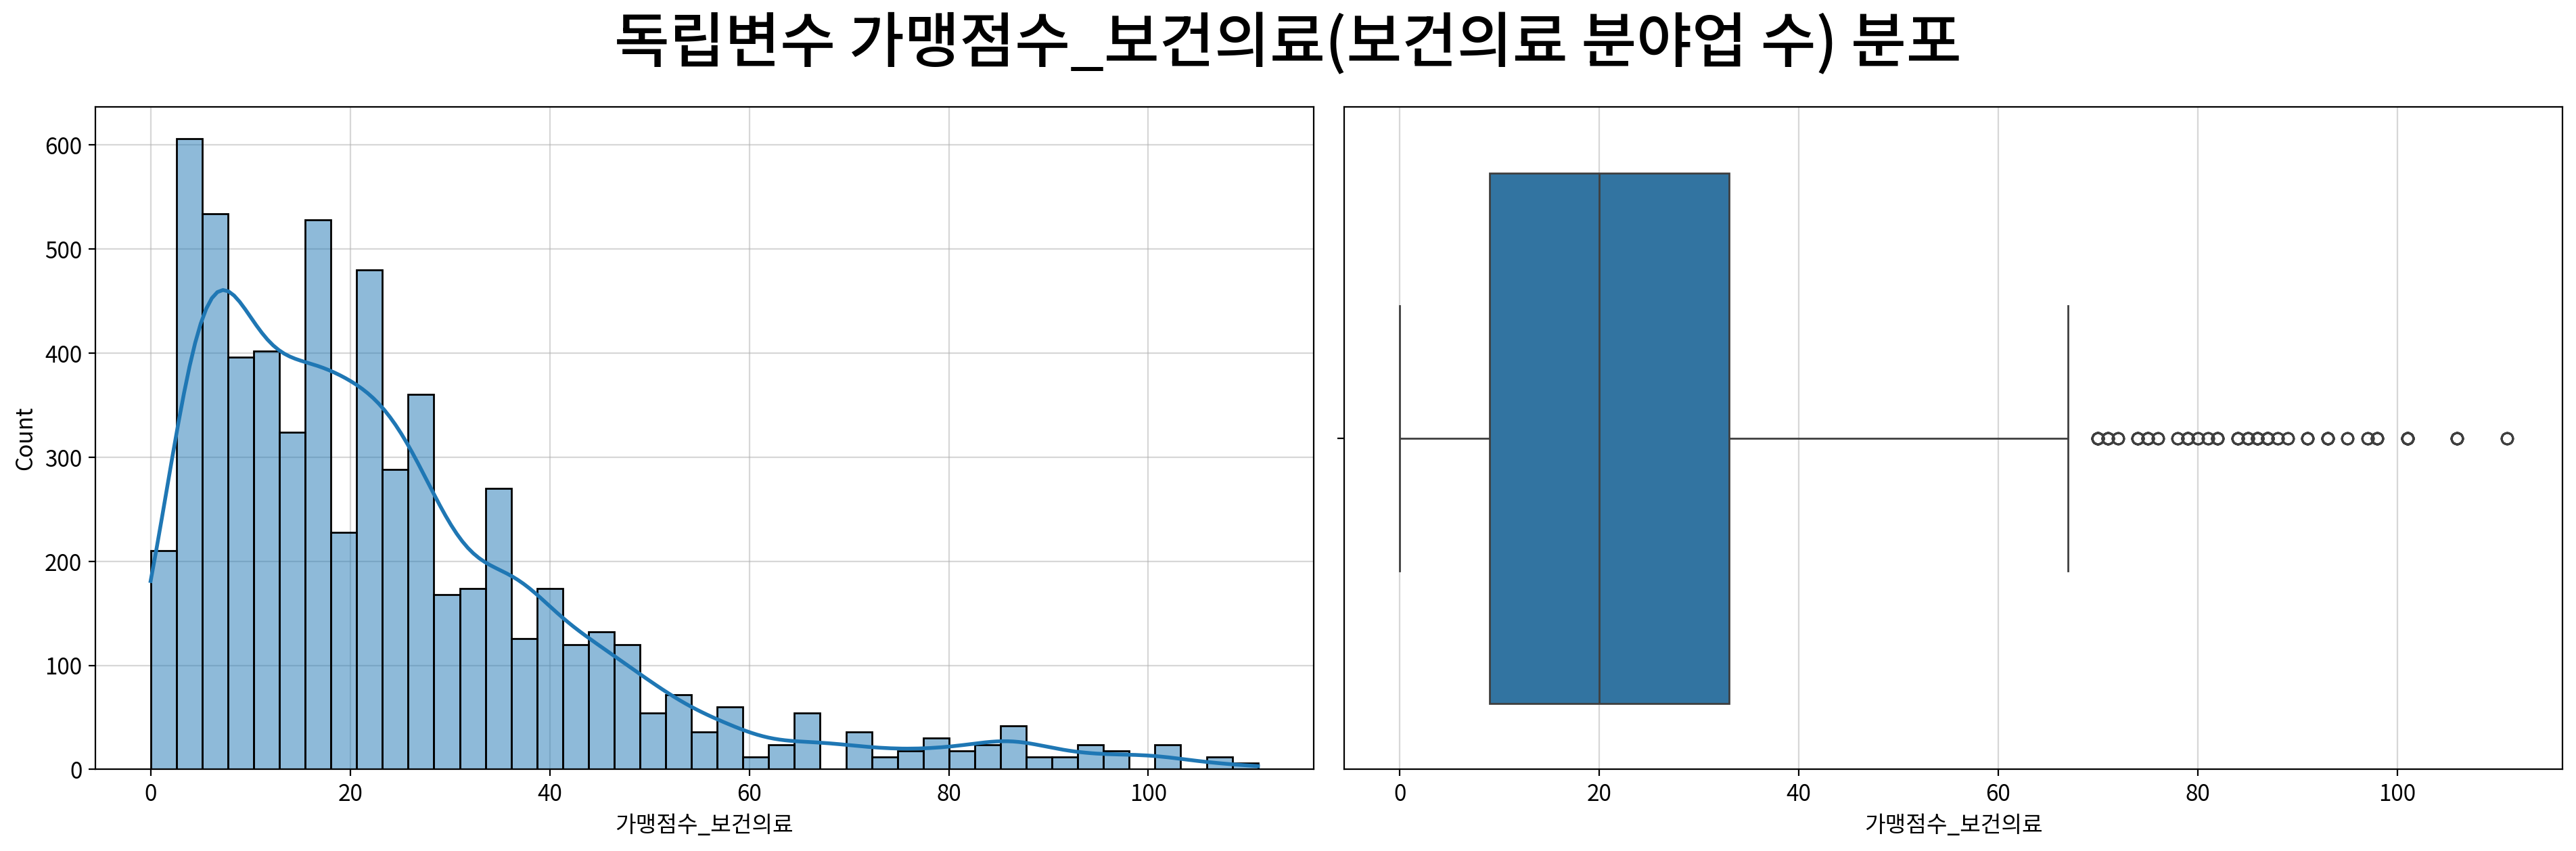

,가맹점수_보건의료
count,6240
mean,24.150962
std,20.087849
min,0.0
25%,9.0
50%,20.0
75%,33.0
max,111.0
rel_diff,0.207548
rdiff_flag,diff


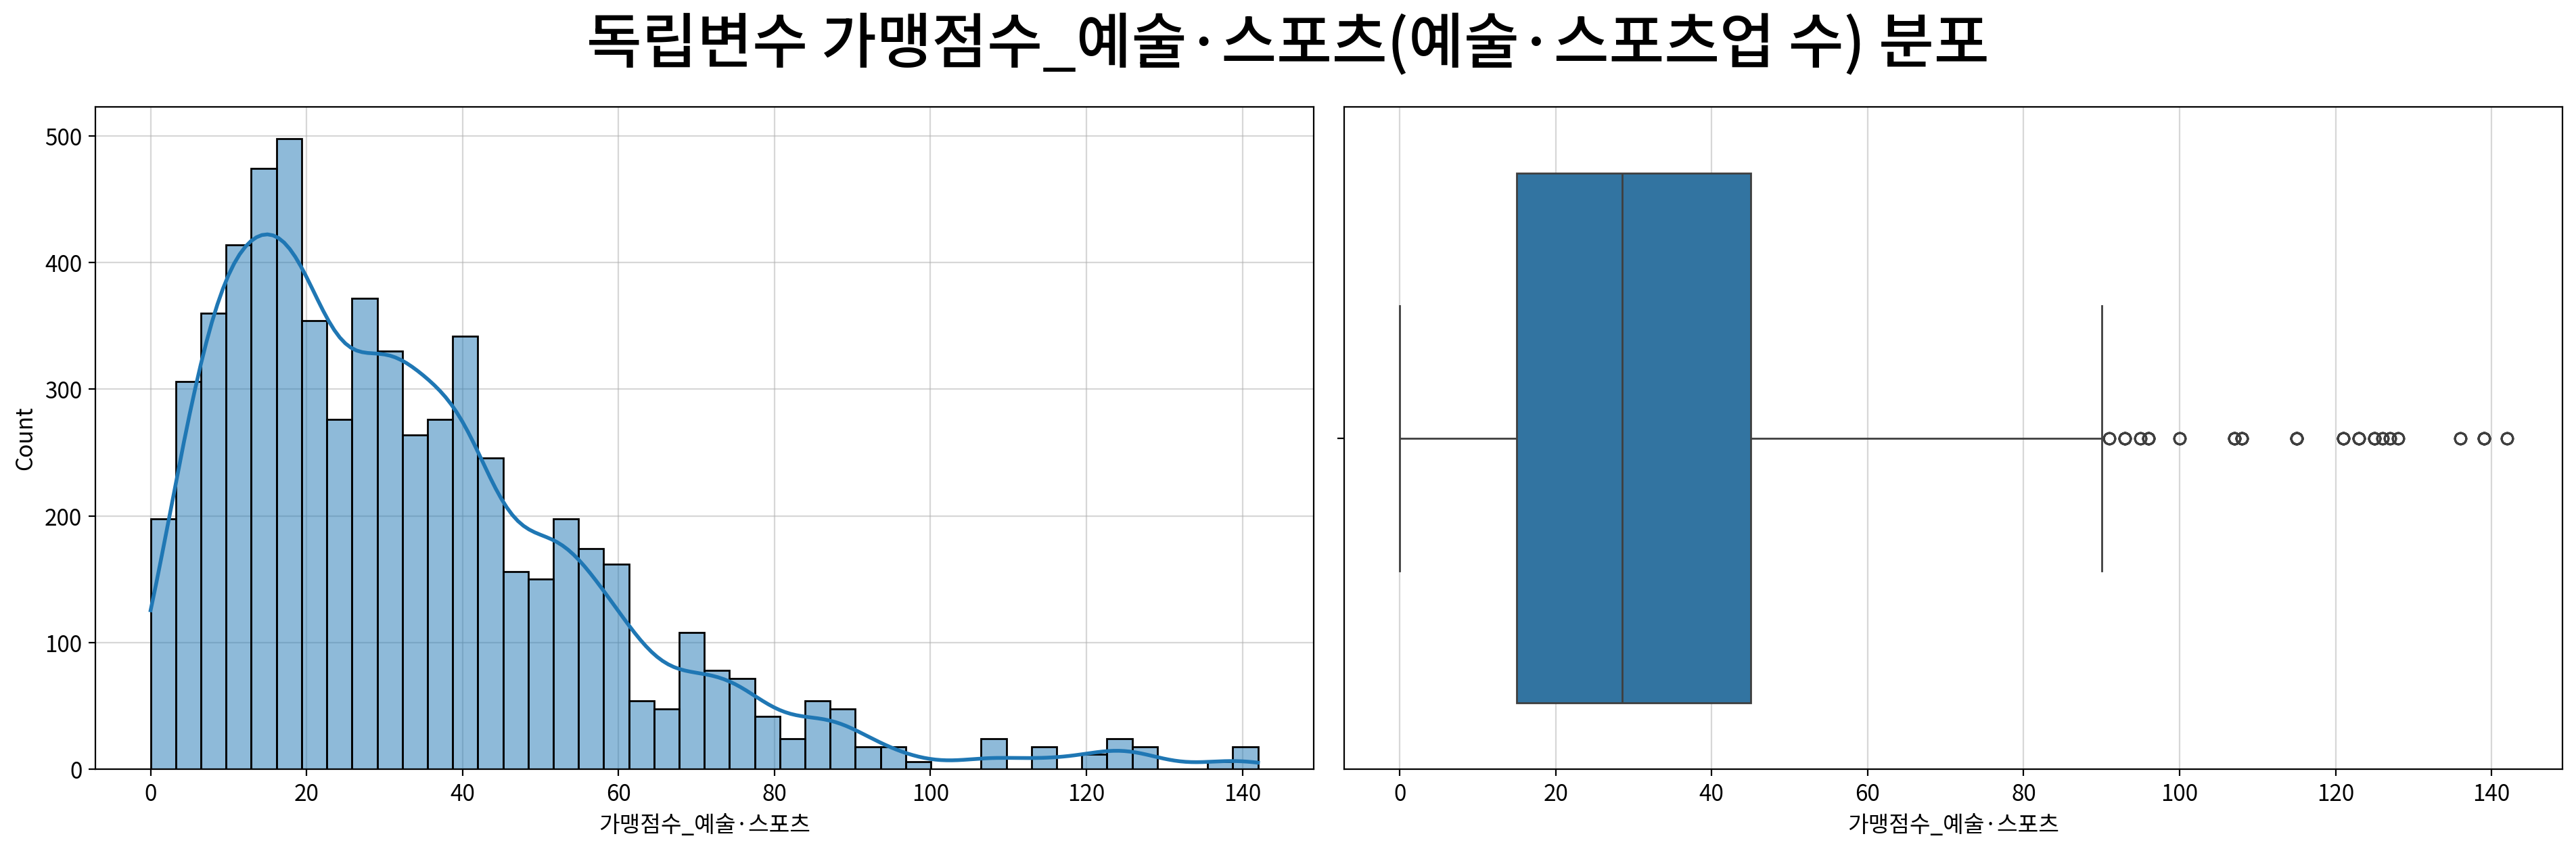

,가맹점수_예술·스포츠
count,6240
mean,33.043269
std,24.4065
min,0.0
25%,15.0
50%,28.5
75%,45.0
max,142.0
rel_diff,0.159413
rdiff_flag,diff


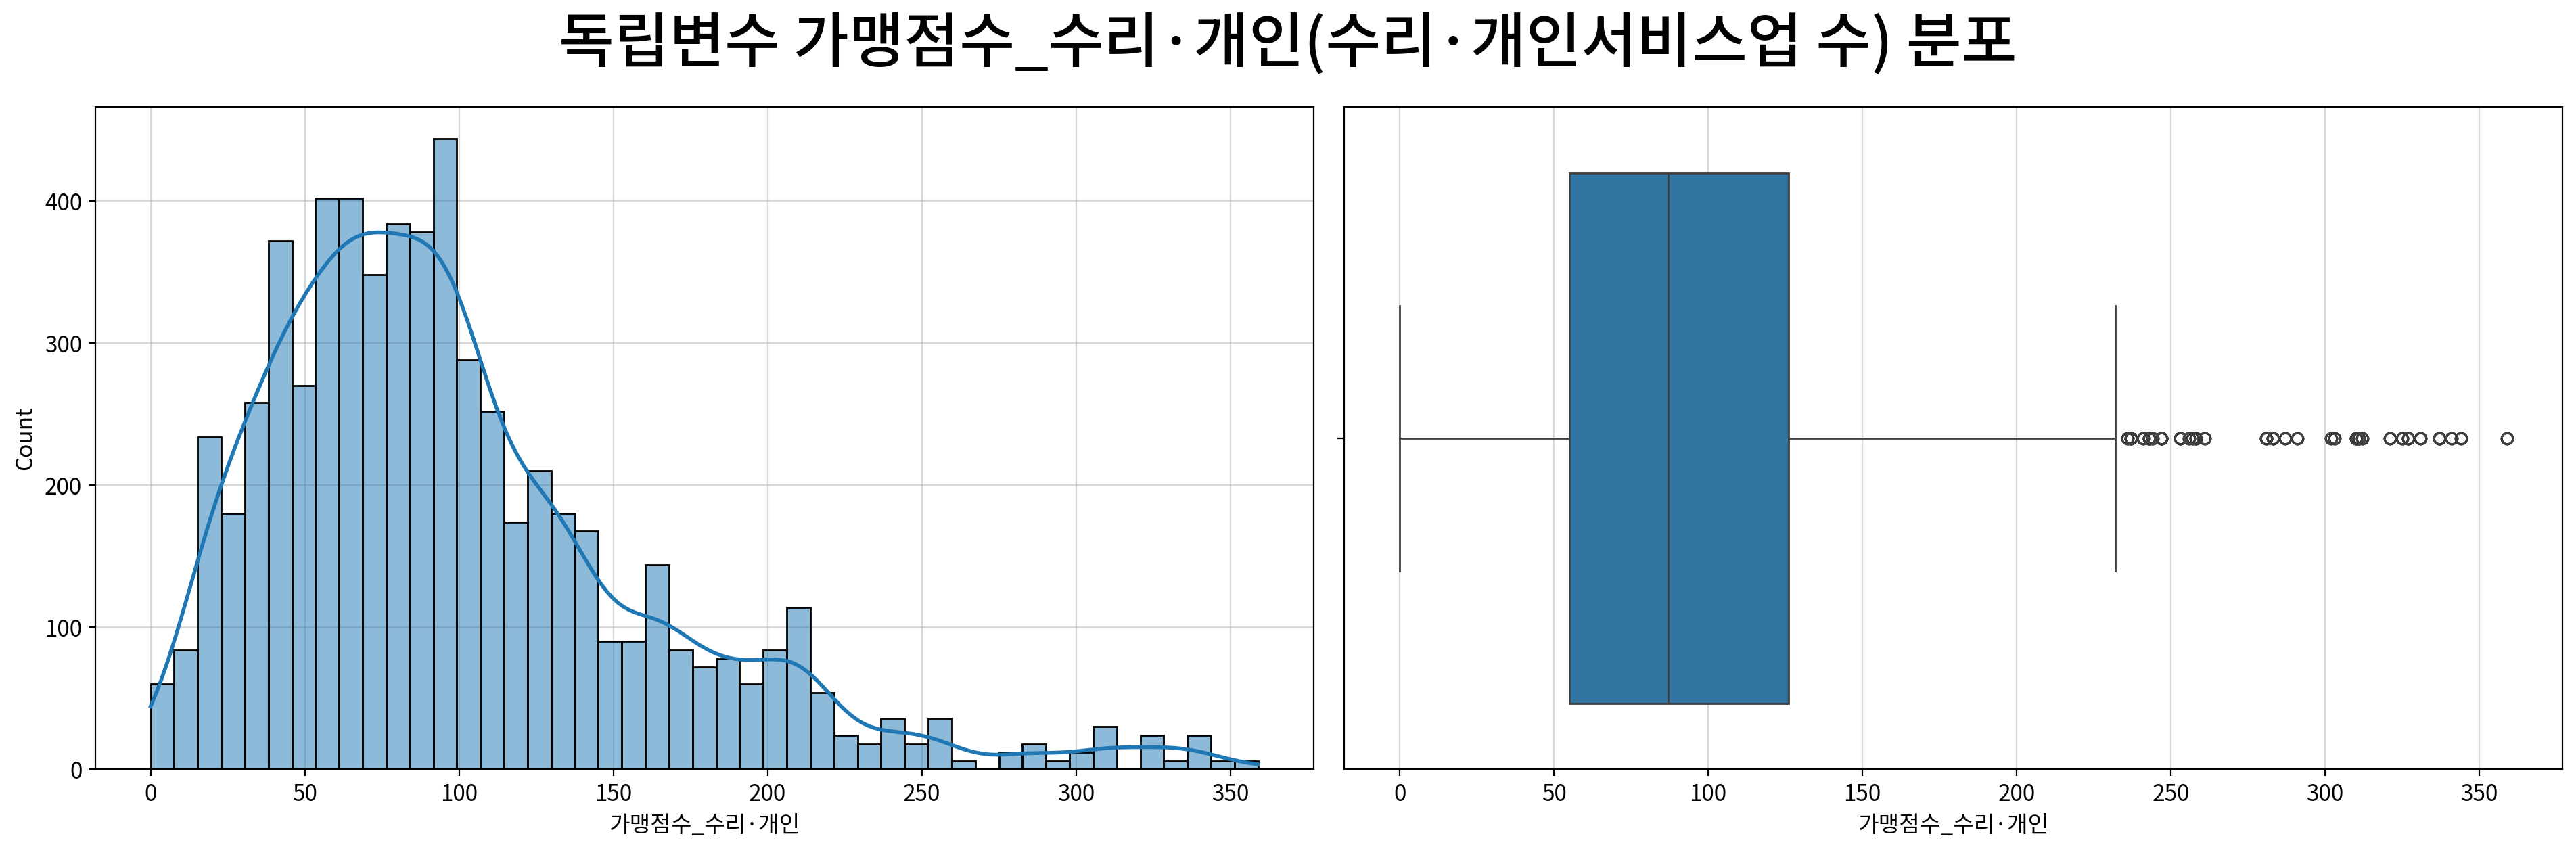

,가맹점수_수리·개인
count,6240
mean,98.939423
std,63.056567
min,0.0
25%,55.0
50%,87.0
75%,126.0
max,359.0
rel_diff,0.137235
rdiff_flag,diff


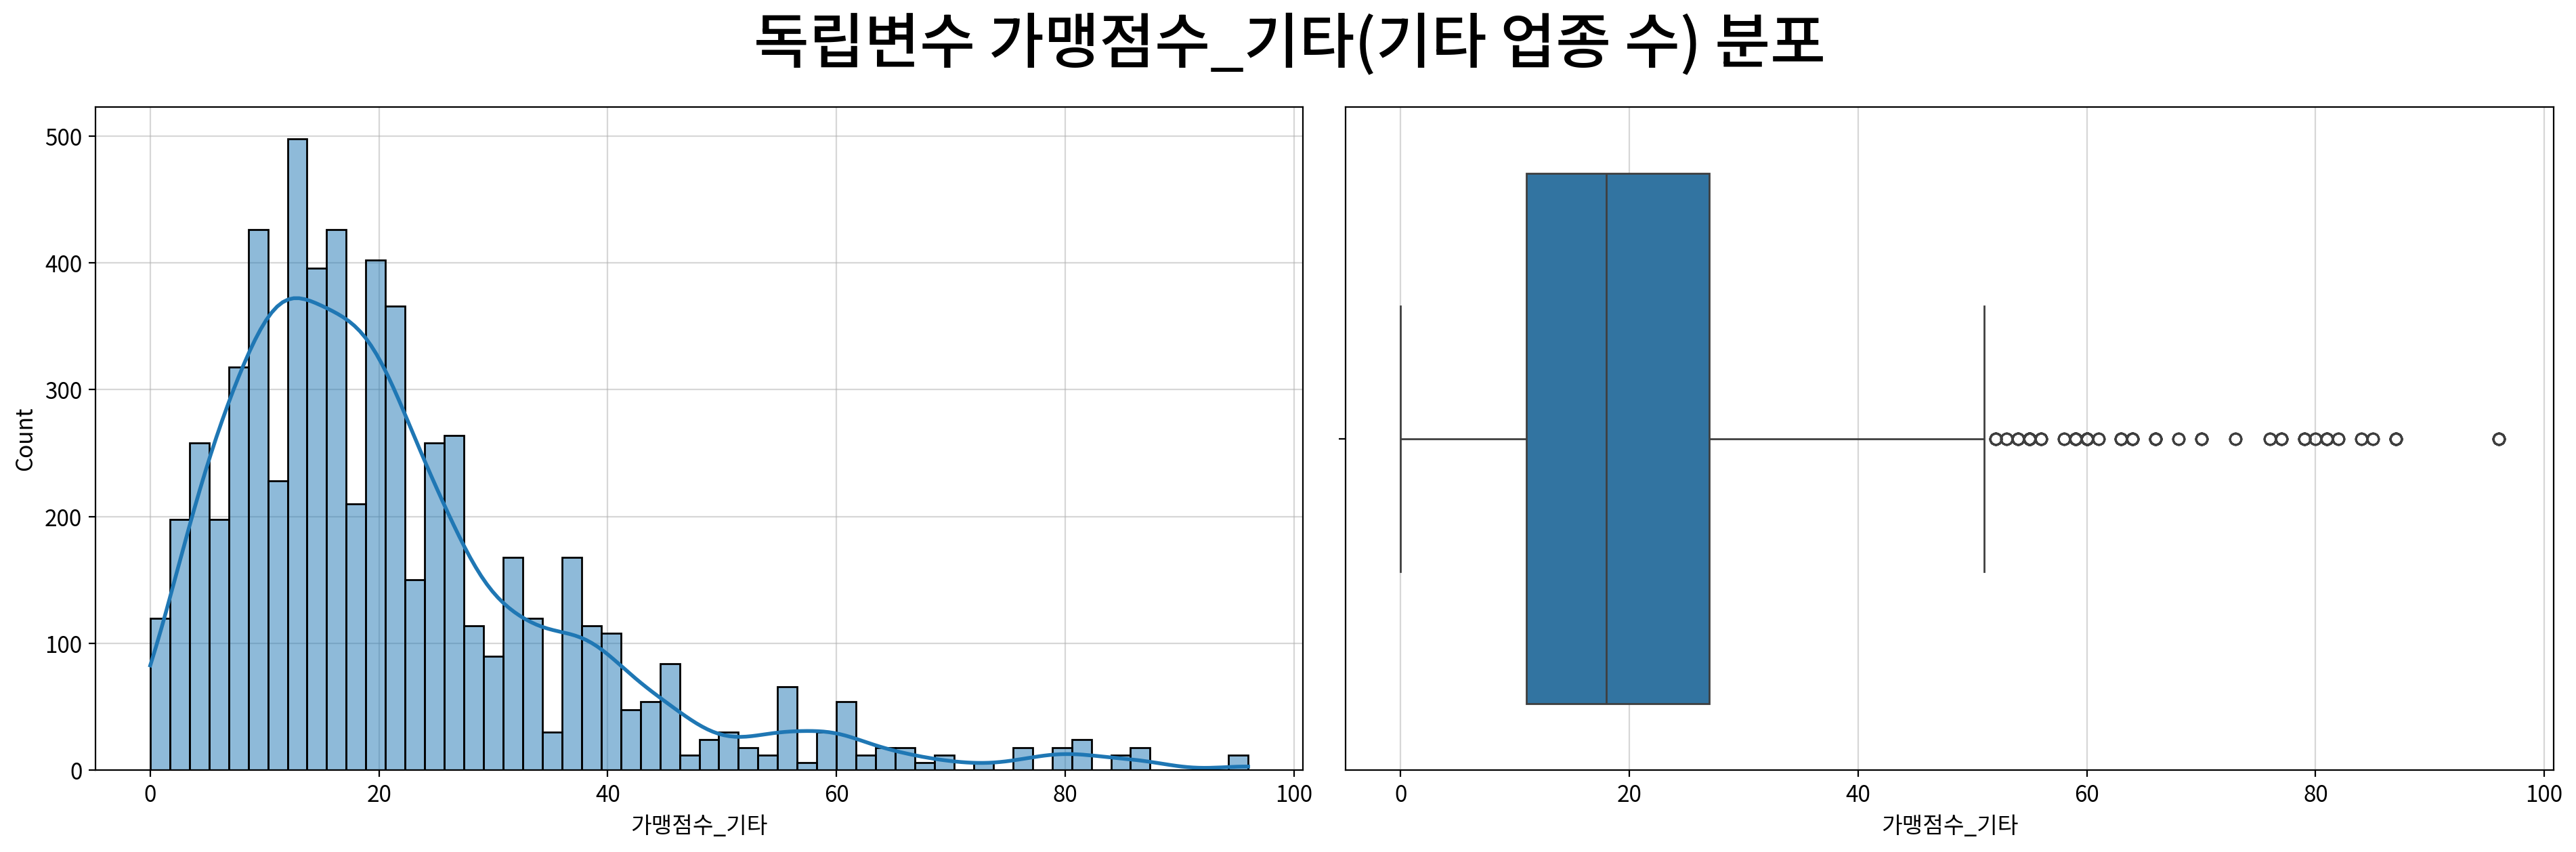

,가맹점수_기타
count,6240
mean,21.418269
std,15.802345
min,0.0
25%,11.0
50%,18.0
75%,27.0
max,96.0
rel_diff,0.189904
rdiff_flag,diff


In [24]:
# 2. 연속형 독립변수에 대한 단변량 분석

for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                           title=f"독립변수 {f}({column_means[f]}) 분포")

    my_plot.histplot(data=df3, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df3, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

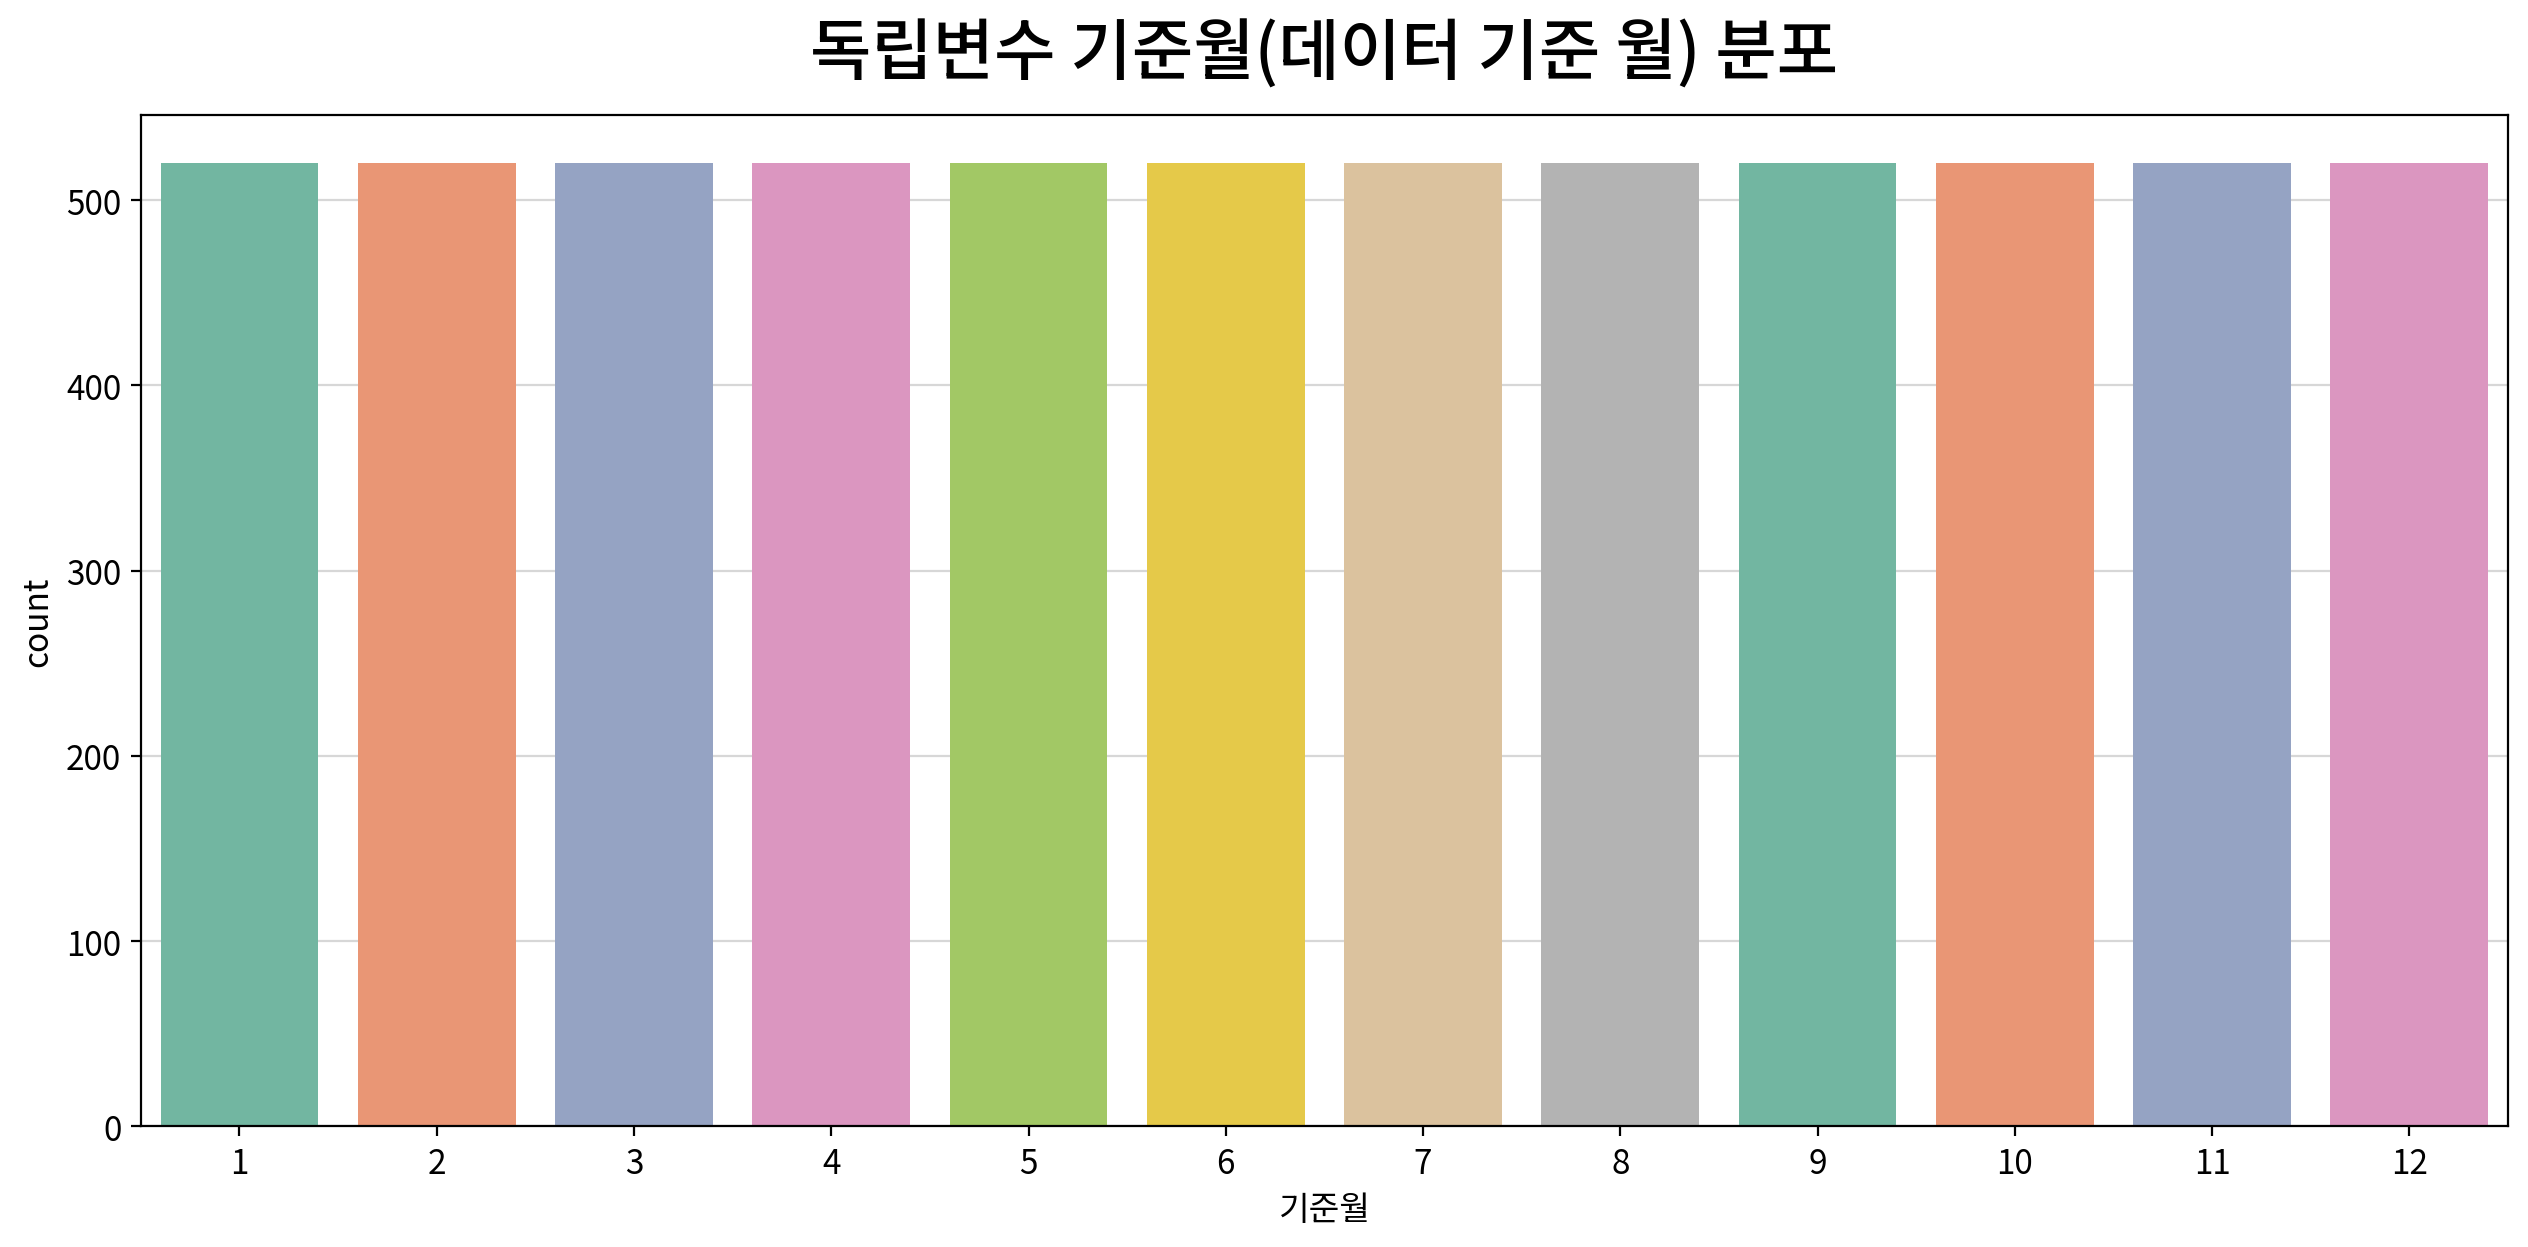

,count,unique,top,freq
기준월,6240,12,1,520


,빈도,비율
기준월,,
1,520,0.083333
2,520,0.083333
3,520,0.083333
4,520,0.083333
5,520,0.083333
6,520,0.083333
7,520,0.083333
8,520,0.083333
9,520,0.083333


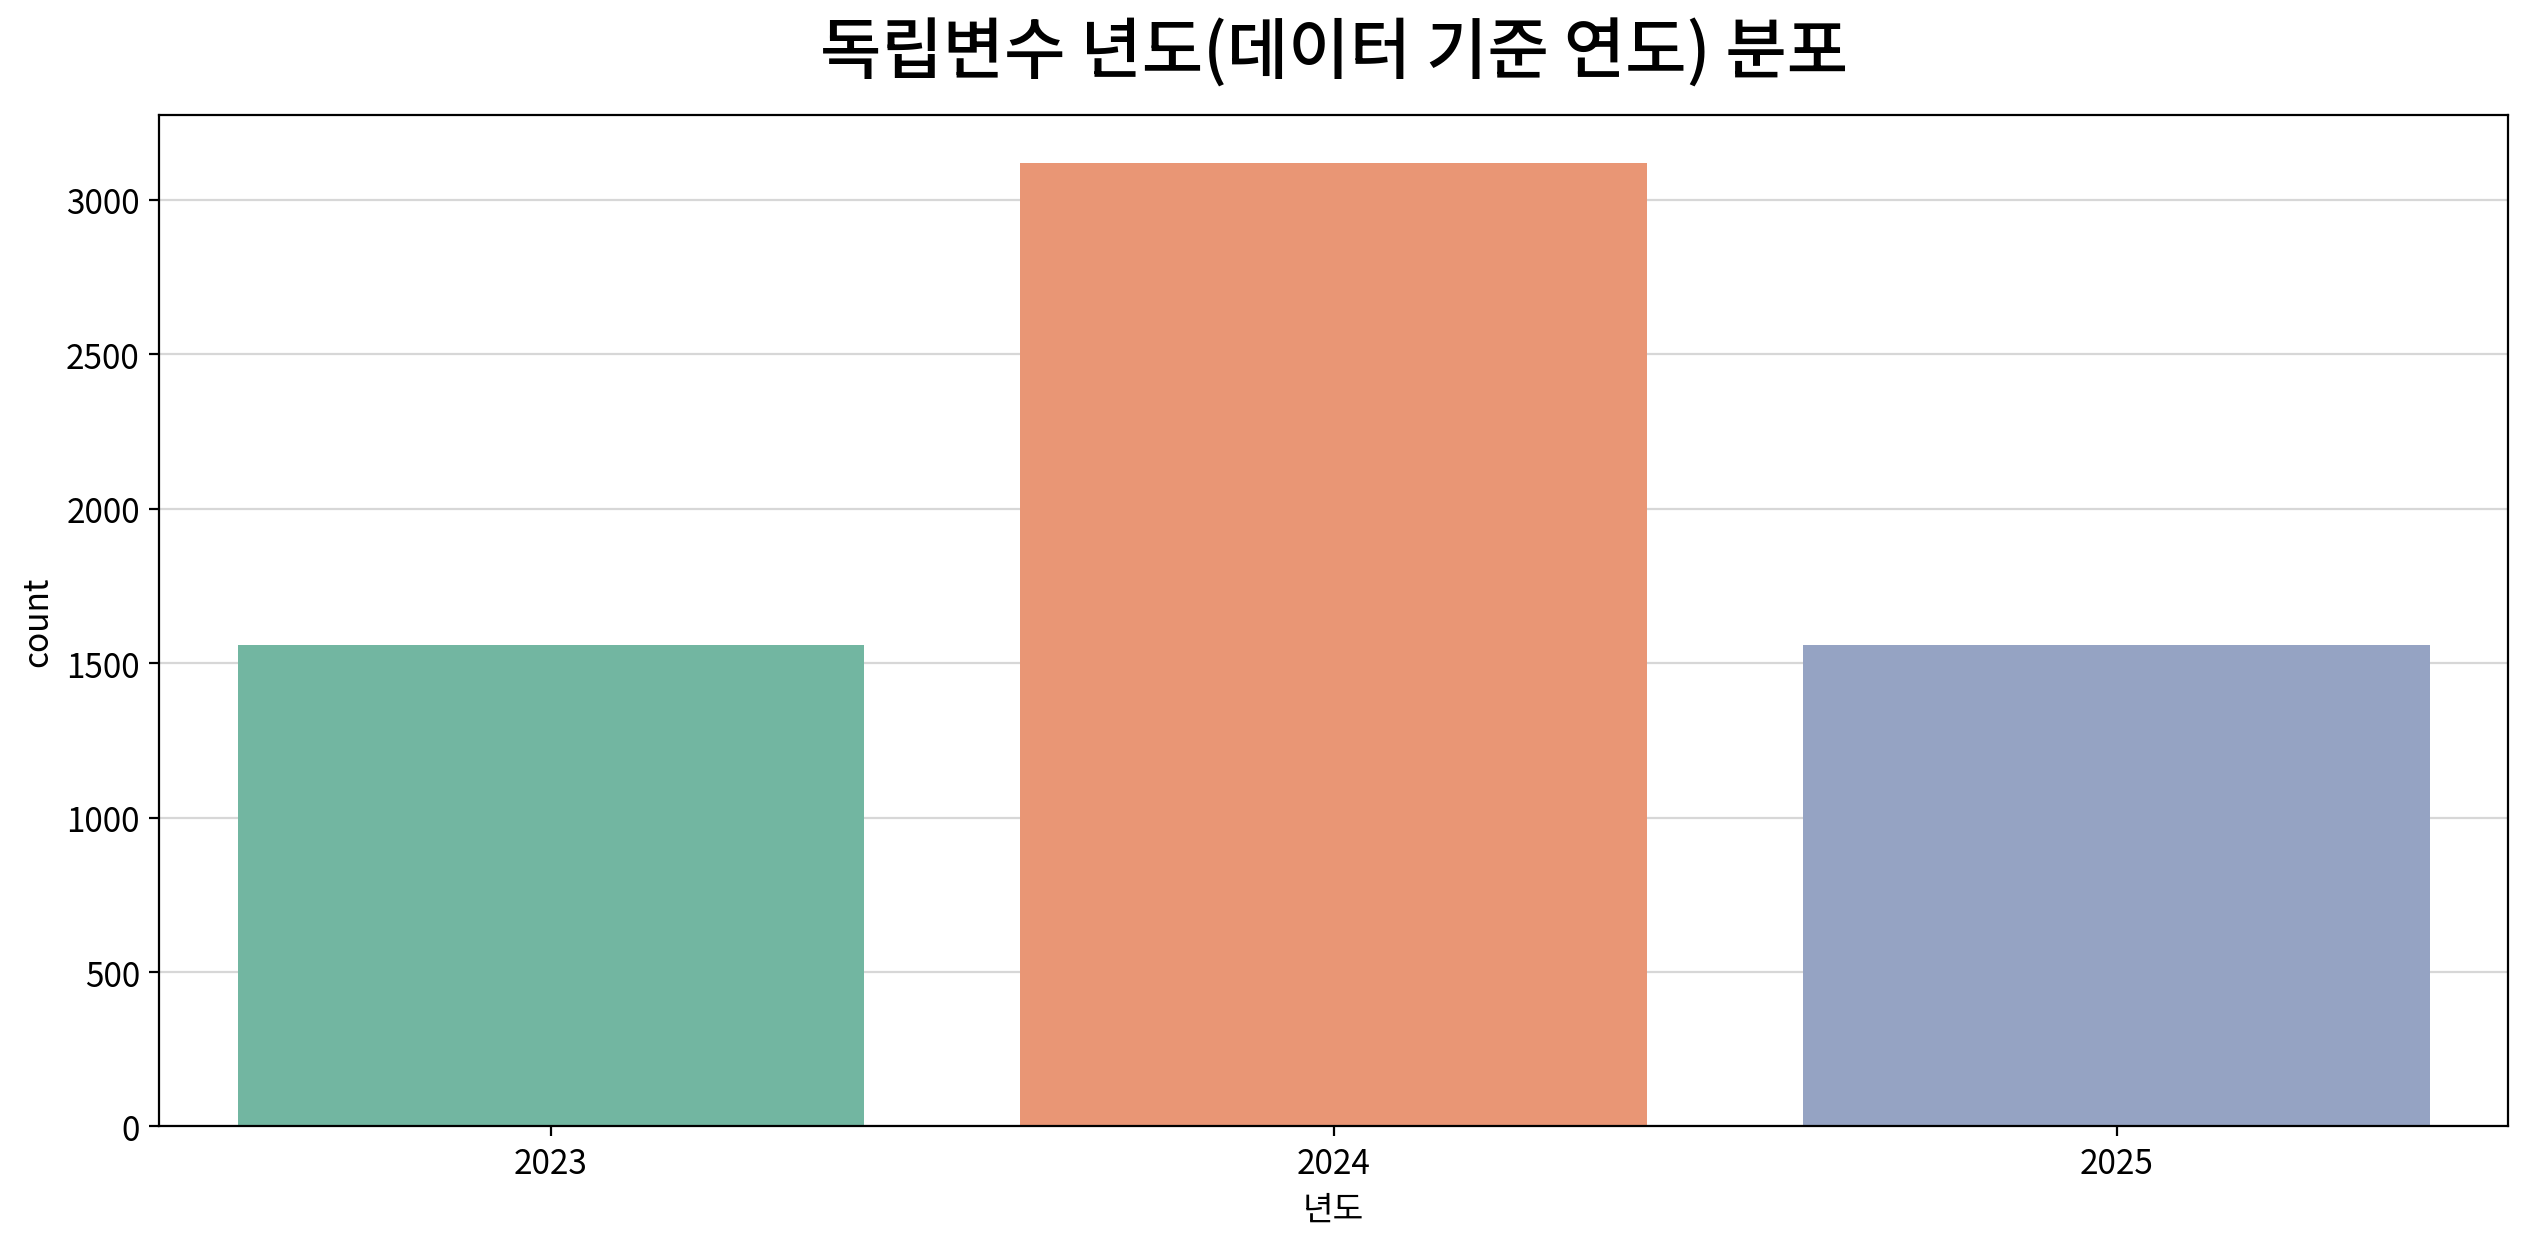

,count,unique,top,freq
년도,6240,3,2024,3120


,빈도,비율
년도,,
2024,3120,0.50
2023,1560,0.25
2025,1560,0.25


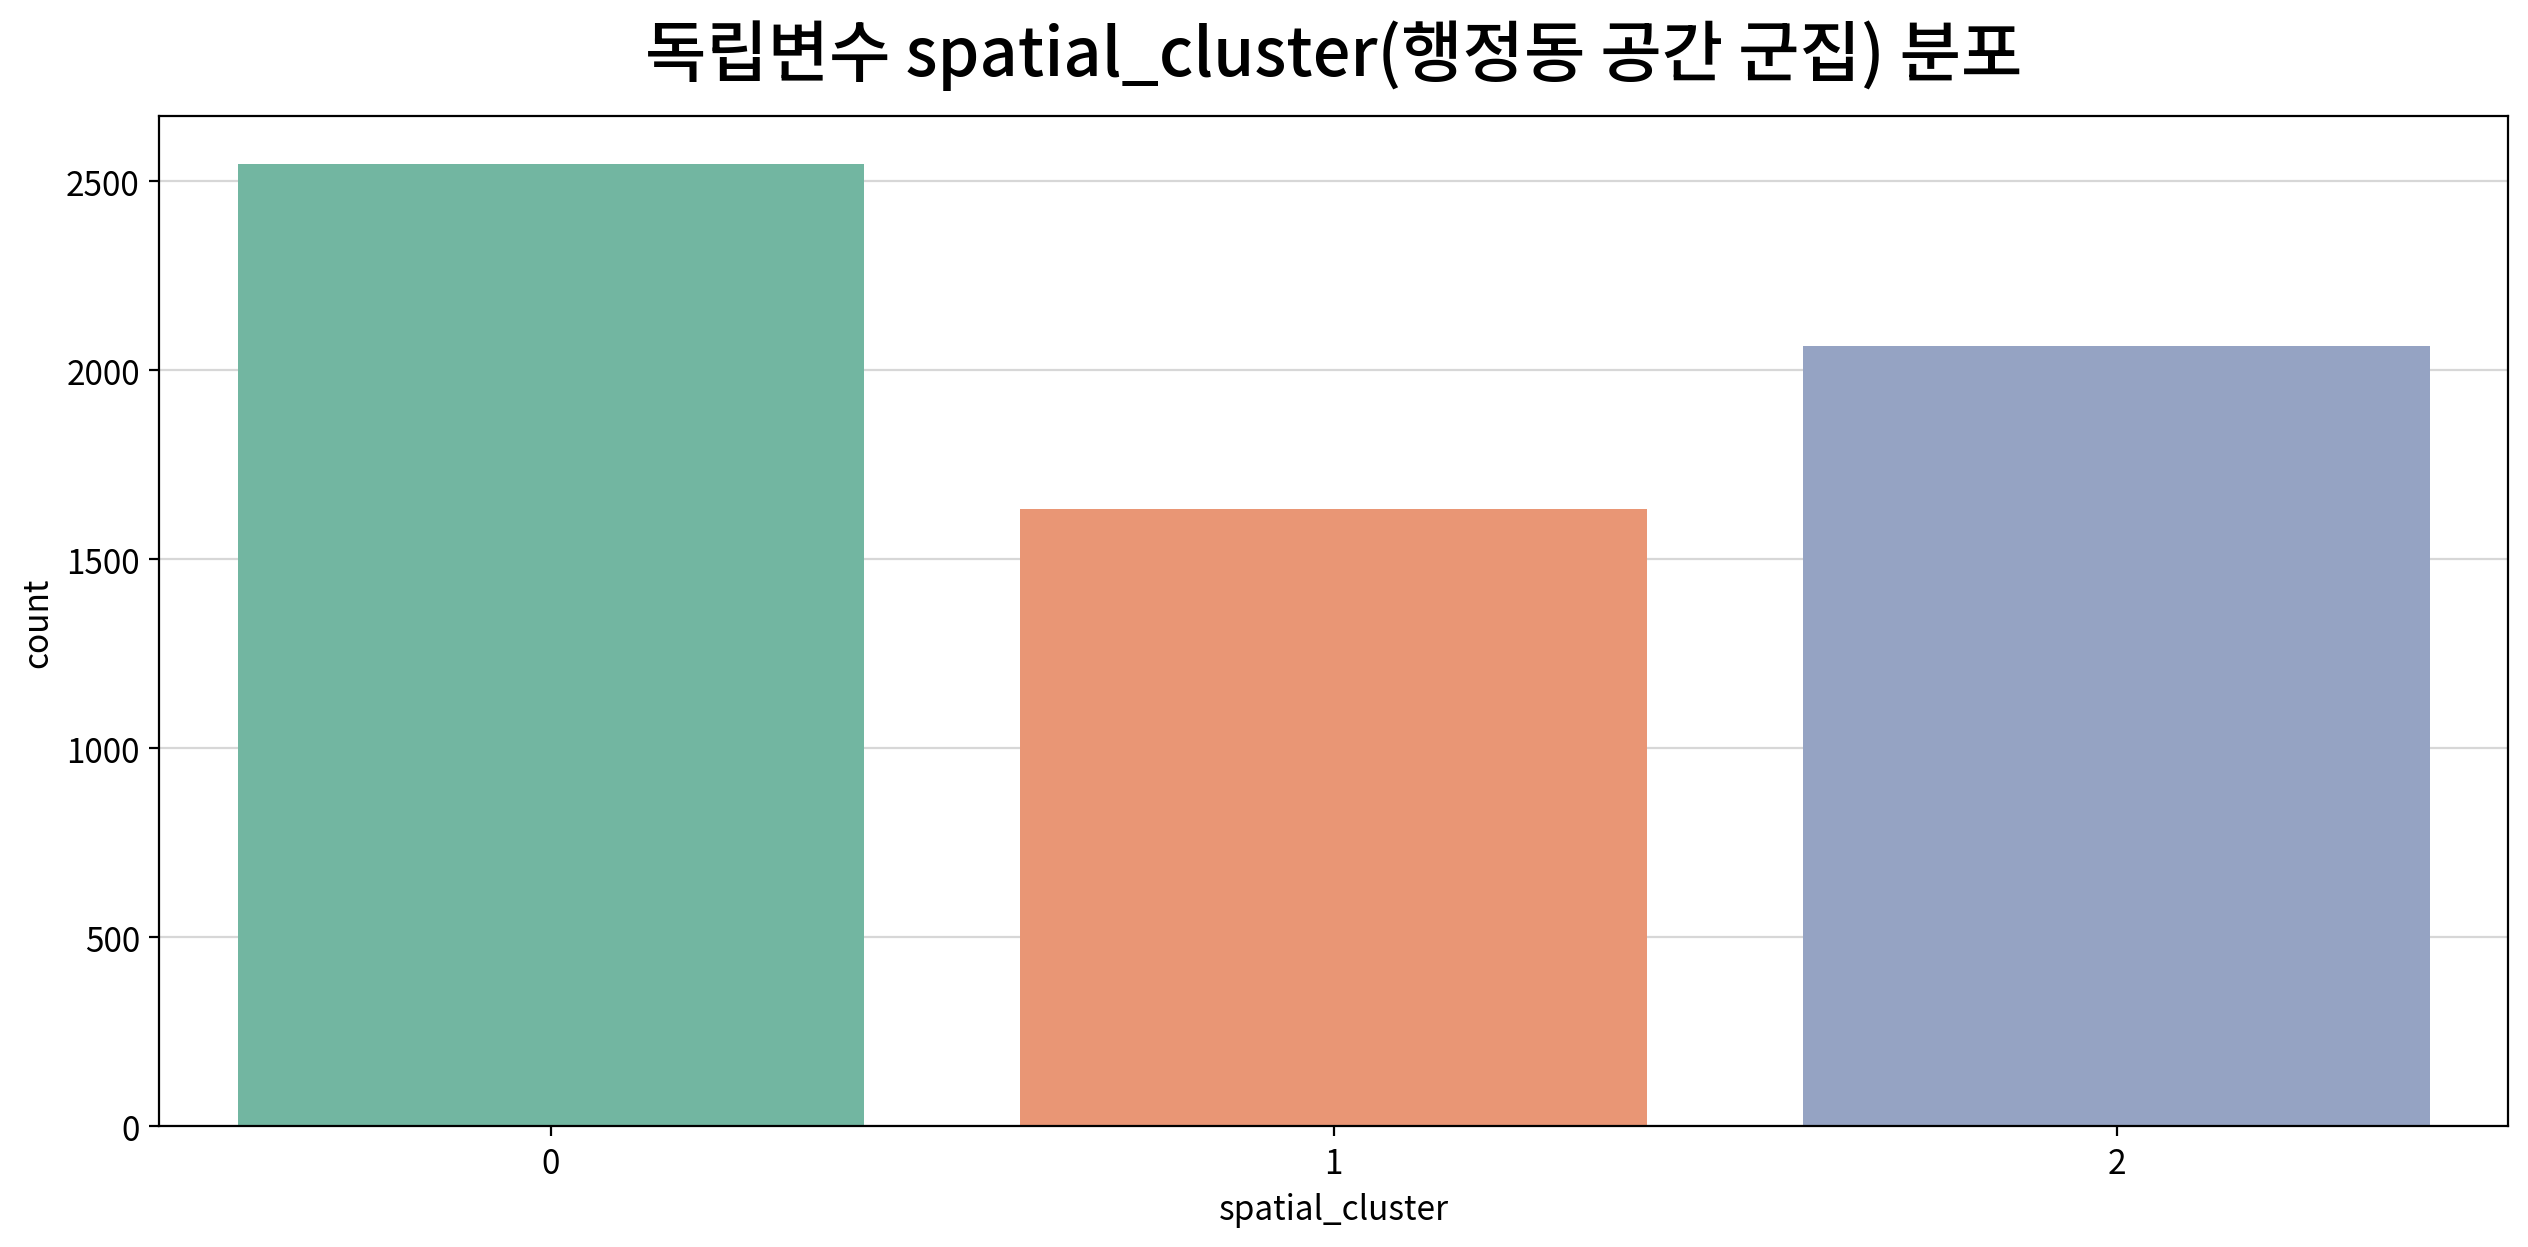

,count,unique,top,freq
spatial_cluster,6240,3,0,2544


,빈도,비율
spatial_cluster,,
0,2544,0.407692
2,2064,0.330769
1,1632,0.261538


In [25]:
# 3. 명목형 독립변수에 대한 단변량 분석

for n in nominal_cols:
    # 명목형 분포는 카운트플롯으로 처리한다.
    my_plot.countplot(data=df3, x=n, hue=n, palette="Set2", title=f"독립변수 {n}({column_means[n]}) 분포")

    # 명목형 기술통계량
    display(cat_desc[[n]].T)

    # 추가적으로 빈도표 생성
    freq = df3[n].value_counts().rename("빈도").to_frame()
    # value_counts(normalize=True)
    # --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
    freq["비율"] = df3[n].value_counts(normalize=True)
    display(freq)

In [26]:
corr_list = []

for f in continuous_cols:
    corr_list.append(my_stats.correlation(df3, x=f, y=target, plot=False))

# 11개 결과를 한 표로 합쳐 상관계수 내림차순 정렬
corr_result = concat(corr_list).sort_values("coef", ascending=False)
display(corr_result)

print("[ 상관 강도 판정별 변수 개수 ]")
print(corr_result['strength'].value_counts())

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
가맹점수_소매,매출금액,Spearman,0.2706,0.0000,Weak,True,False,False,True,True,True
가맹점수_수리·개인,매출금액,Spearman,0.2292,0.0000,Weak,True,False,False,False,True,True
가맹점수_예술·스포츠,매출금액,Spearman,0.2231,0.0000,Weak,True,False,False,True,True,True
가맹점수_음식,매출금액,Spearman,0.2120,0.0000,Weak,True,False,False,False,True,True
행정동코드,매출금액,Spearman,0.1976,0.0000,Weak,True,False,False,True,True,True
가맹점수_기타,매출금액,Spearman,0.1893,0.0000,Weak,True,False,False,False,True,True
총인구수,매출금액,Spearman,0.1856,0.0000,Weak,True,False,False,False,True,True
가맹점수_보건의료,매출금액,Spearman,0.1741,0.0000,Weak,True,False,False,False,True,True
가맹점수_부동산,매출금액,Spearman,0.1476,0.0000,Weak,True,False,False,False,True,True


[ 상관 강도 판정별 변수 개수 ]
strength
Weak    14
Name: count, dtype: int64


In [27]:
# 2. T-Test(x: 2집단 명목형 독립변수 -> y: 종속변수)
for n in nominal_cols:
    # 2개의 고유값을 가지는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) == 2:
        # 빈 줄 출력용
        print()

        # 분석 단위 제목 출력
        display(Markdown(f"#### 🧪 {n}({column_means[n]}) → {target}"))

        # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
        wide_df = my_prep.long2wide(df3, hue=n, values=target)
        display(my_stats.test_independent(wide_df,
                                          group1=wide_df.columns[0], group2=wide_df.columns[1]))

In [28]:
# 3. ANOVA(x: 3집단 명목형 독립변수 -> y: 종속변수) 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정
for n in nominal_cols:
    # 3개 이상의 고유값이 존재하는 명목형 독립변수에 대해서만 검정을 수행한다.
    if len(df3[n].unique()) >= 3:
        print()  # 빈 줄 출력용

        # 분석 단위 제목 출력
        display(Markdown(f"#### 🧪 {n}({column_means[n]}) → {target}"))

        # origin이 아닌 df를 사용해야 서열척도로 지정한 범주 순서가 반영된다.
        display(my_stats.anova_oneway(df3, y=target, between=n))
        display(my_stats.posthoc_oneway(df3, y=target, between=n, plot=False))

#### 🧪 기준월(데이터 기준 월) → 매출금액

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,기준월,11,2451.852911,9.598803,3.504704e-17,0.033682,Small


비교한 조합 쌍: 66개
유의한 쌍: 11개
평균 차이가 가장 큰 쌍: (5) vs (7) → 차이 51394363.096, 효과크기 Medium, p-value 0.000
평균 차이가 가장 작은 쌍: (2) vs (12) → 차이 44872.067, 효과크기 Negligible, p-value 1.000


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,1,2,1.506470e+07,1.562083e+07,-5.561328e+05,4.759248e+06,-0.116853,1031.891931,1.000000,-0.007242,False,Negligible
1,Games-Howell,1,3,1.506470e+07,1.235589e+07,2.708803e+06,4.305938e+06,0.629085,1021.358704,0.999974,0.038986,False,Negligible
2,Games-Howell,1,4,1.506470e+07,1.273438e+07,2.330320e+06,4.239294e+06,0.549695,1011.013584,0.999993,0.034066,False,Negligible
3,Games-Howell,1,5,1.506470e+07,1.202463e+07,3.040069e+06,4.104636e+06,0.740643,981.038014,0.999865,0.045900,False,Negligible
4,Games-Howell,1,6,1.506470e+07,1.359631e+07,1.468384e+06,4.309579e+06,0.340726,1021.843933,1.000000,0.021116,False,Negligible
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Games-Howell,9,11,1.715364e+07,1.437862e+07,2.775021e+06,4.565957e+06,0.607763,1002.657207,0.999982,0.037665,False,Negligible
62,Games-Howell,9,12,1.715364e+07,1.557596e+07,1.577687e+06,4.745854e+06,0.332435,1027.842840,1.000000,0.020602,False,Negligible
63,Games-Howell,10,11,1.461141e+07,1.437862e+07,2.327882e+05,4.195077e+06,0.055491,1036.520627,1.000000,0.003439,False,Negligible
64,Games-Howell,10,12,1.461141e+07,1.557596e+07,-9.645456e+05,4.390198e+06,-0.219704,1035.155693,1.000000,-0.013616,False,Negligible


#### 🧪 년도(데이터 기준 연도) → 매출금액

...

,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,2023,2024,3.415522e+07,1.327793e+07,2.087729e+07,2.559970e+06,8.155288,2325.321669,1.001088e-12,0.284680,True,Small
1,Games-Howell,2023,2025,3.415522e+07,1.460839e+07,1.954683e+07,2.969889e+06,6.581669,2998.299640,1.640700e-10,0.235605,True,Small
2,Games-Howell,2024,2025,1.327793e+07,1.460839e+07,-1.330465e+06,2.188859e+06,-0.607835,2700.907381,8.158521e-01,-0.019918,False,Negligible


#### 🧪 spatial_cluster(행정동 공간 군집) → 매출금액

,test,Source,ddof1,ddof2,F,p_unc,np2,effect_size
0,welch_anova,spatial_cluster,2,4006.2541,23.103218,1.056380e-10,0.005403,Negligible


비교한 조합 쌍: 3개
유의한 쌍: 3개
평균 차이가 가장 큰 쌍: (1) vs (2) → 차이 14104473.160, 효과크기 Small, p-value 0.000
평균 차이가 가장 작은 쌍: (0) vs (1) → 차이 6327814.116, 효과크기 Negligible, p-value 0.002


,test,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,significant,effect_size
0,Games-Howell,0,1,1.791255e+07,1.158474e+07,6.327814e+06,1.861376e+06,3.399537,4003.939337,1.969860e-03,0.094810,True,Negligible
1,Games-Howell,0,2,1.791255e+07,2.568921e+07,-7.776659e+06,2.467457e+06,-3.151690,4230.392109,4.656112e-03,-0.094227,True,Negligible
2,Games-Howell,1,2,1.158474e+07,2.568921e+07,-1.410447e+07,2.152795e+06,-6.551703,3066.730120,2.014947e-10,-0.201294,True,Small


In [29]:
corr = my_stats.multi_correlation(df3, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,행정동코드,총인구수,월유동인구수,가맹점수_소매,가맹점수_숙박,가맹점수_음식,가맹점수_부동산,가맹점수_과학·기술,가맹점수_시설관리·임대,가맹점수_교육,가맹점수_보건의료,가맹점수_예술·스포츠,가맹점수_수리·개인,가맹점수_기타
행정동코드,1.000,0.094,-0.330,0.085,0.016,0.052,0.062,0.046,0.070,0.147,0.042,0.082,0.065,0.114
총인구수,0.094,1.000,0.234,0.520,-0.069,0.561,0.311,0.356,0.427,0.779,0.569,0.645,0.688,0.527
월유동인구수,-0.330,0.234,1.000,0.185,0.023,0.197,0.153,0.198,0.218,0.259,0.388,0.281,0.259,0.266
가맹점수_소매,0.085,0.520,0.185,1.000,0.433,0.881,0.460,0.685,0.468,0.394,0.701,0.793,0.846,0.760
가맹점수_숙박,0.016,-0.069,0.023,0.433,1.000,0.427,0.209,0.346,0.148,-0.149,0.315,0.276,0.298,0.327
가맹점수_음식,0.052,0.561,0.197,0.881,0.427,1.000,0.476,0.716,0.514,0.488,0.680,0.869,0.894,0.783
가맹점수_부동산,0.062,0.311,0.153,0.460,0.209,0.476,1.000,0.281,0.335,0.265,0.337,0.469,0.454,0.455
가맹점수_과학·기술,0.046,0.356,0.198,0.685,0.346,0.716,0.281,1.000,0.348,0.383,0.595,0.625,0.704,0.676
가맹점수_시설관리·임대,0.070,0.427,0.218,0.468,0.148,0.514,0.335,0.348,1.000,0.475,0.516,0.614,0.548,0.529
가맹점수_교육,0.147,0.779,0.259,0.394,-0.149,0.488,0.265,0.383,0.475,1.000,0.630,0.628,0.601,0.510


,max-y,max-coef,count,columns
x,,,,
가맹점수_수리·개인,가맹점수_음식,0.8941,6,"가맹점수_음식, 가맹점수_예술·스포츠, 가맹점수_소매, 가맹점수_기타, 가맹점수_보..."
가맹점수_음식,가맹점수_수리·개인,0.8941,5,"가맹점수_수리·개인, 가맹점수_소매, 가맹점수_예술·스포츠, 가맹점수_기타, 가맹점..."
가맹점수_소매,가맹점수_음식,0.8806,5,"가맹점수_음식, 가맹점수_수리·개인, 가맹점수_예술·스포츠, 가맹점수_기타, 가맹점..."
가맹점수_예술·스포츠,가맹점수_음식,0.8689,5,"가맹점수_음식, 가맹점수_수리·개인, 가맹점수_소매, 가맹점수_보건의료, 가맹점수_기타"
가맹점수_기타,가맹점수_음식,0.7827,4,"가맹점수_음식, 가맹점수_수리·개인, 가맹점수_소매, 가맹점수_예술·스포츠"
가맹점수_보건의료,가맹점수_예술·스포츠,0.7475,3,"가맹점수_예술·스포츠, 가맹점수_수리·개인, 가맹점수_소매"
가맹점수_과학·기술,가맹점수_음식,0.7158,2,"가맹점수_음식, 가맹점수_수리·개인"
가맹점수_교육,총인구수,0.7789,1,총인구수
총인구수,가맹점수_교육,0.7789,1,가맹점수_교육


In [36]:
derived_num_desc = my_qtcheck.numerical_summary(df3, columns=derived_continuous)
derived_num_desc[['mean', '50%', 'skew', 'kurt', 'outliers_ratio', 'log_need']]

,mean,50%,skew,kurt,outliers_ratio,log_need
가맹점수_소매,209.217308,182.500000,2.106588,8.661639,0.048077,log
가맹점수_숙박,2.947115,1.000000,4.461890,25.959155,0.102885,log1p
가맹점수_음식,255.900962,214.000000,1.561025,3.176819,0.045192,log
가맹점수_부동산,0.760577,0.000000,1.678074,2.714819,0.079808,log1p
가맹점수_과학·기술,9.325000,7.000000,2.758654,12.531850,0.050962,log1p
가맹점수_시설관리·임대,2.758654,2.000000,2.353321,10.330411,0.051923,log1p
가맹점수_교육,76.174038,55.000000,1.796074,4.276104,0.050962,log1p
가맹점수_보건의료,24.150962,20.000000,1.554469,2.722455,0.046154,log1p
가맹점수_예술·스포츠,33.043269,28.500000,1.337263,2.333625,0.025962,log1p
가맹점수_수리·개인,98.939423,87.000000,1.275695,1.928418,0.039423,log1p


#### 이변량 분석 - 상관분석 (연속형 파생 → 종속변수)

In [37]:
corr_list = []

for f in derived_continuous:
    corr_list.append(my_stats.correlation(df3, x=f, y=target, plot=False))

corr_result = concat(corr_list).sort_values("coef", ascending=False)
display(corr_result)

print("[ 상관 강도 판정별 변수 개수 ]")
print(corr_result['strength'].value_counts())

,,method,coef,p-value,strength,significant,normality_x,normality_y,linearity,influential_outlier,high_skew
x,y,,,,,,,,,,
가맹점수_소매,매출금액,Spearman,0.2706,0.000,Weak,True,False,False,True,True,True
가맹점수_수리·개인,매출금액,Spearman,0.2292,0.000,Weak,True,False,False,False,True,True
가맹점수_예술·스포츠,매출금액,Spearman,0.2231,0.000,Weak,True,False,False,True,True,True
가맹점수_음식,매출금액,Spearman,0.2120,0.000,Weak,True,False,False,False,True,True
가맹점수_기타,매출금액,Spearman,0.1893,0.000,Weak,True,False,False,False,True,True
가맹점수_보건의료,매출금액,Spearman,0.1741,0.000,Weak,True,False,False,False,True,True
가맹점수_부동산,매출금액,Spearman,0.1476,0.000,Weak,True,False,False,False,True,True
가맹점수_과학·기술,매출금액,Spearman,0.1431,0.000,Weak,True,False,False,False,True,True
가맹점수_시설관리·임대,매출금액,Spearman,0.1002,0.000,Weak,True,False,False,False,False,True


[ 상관 강도 판정별 변수 개수 ]
strength
Weak    12
Name: count, dtype: int64


In [38]:
# 이번 단원의 검증 결과를 반영해 모형에 투입할 변수를 확정한다.
# -> condition_grp        : 병합 후에도 비유의(p=0.490) → 보류가 아니라 제외로 결론
# -> density_vs_neighbor  : 상관 최약(+0.172)에 왜도 최악(+21.9) → 제외
feature_cols = [
    "부동산_비율",
    "소매_비율",
    "예술·스포츠_비율",
    "교육_비율",
    "총인구수",
    "월유동인구수",
    "spatial_cluster",
    "기준월",
    "년도"
]

print("투입 변수 :", len(feature_cols), "종")
print("투입 변수 목록 :", feature_cols)

# 저장 대상 = 투입 변수 + 종속변수
save_cols = feature_cols + [target]

# 로그 변환·라벨링 전, 원 단위 그대로의 상태를 먼저 남긴다.
df_derived = df3[save_cols]
df_derived = my_qtcheck.set_type(df_derived,
                    as_category=["spatial_cluster", "기준월", "년도"])

df_derived.to_excel("local_features.xlsx", index=False)
print("저장 완료 :", df_derived.shape)

df_derived.to_parquet("local_features.parquet", index=False)

투입 변수 : 9 종
투입 변수 목록 : ['부동산_비율', '소매_비율', '예술·스포츠_비율', '교육_비율', '총인구수', '월유동인구수', 'spatial_cluster', '기준월', '년도']


KeyError: "['부동산_비율', '소매_비율', '예술·스포츠_비율', '교육_비율'] not in index"

In [ ]:
# 투입 변수만 다시 기술통계량을 내어 로그 변환 대상을 확인한다.
feature_desc = my_qtcheck.numerical_summary(df_derived)
display(feature_desc[["skew", "kurt", "log_need"]])

# log_need 판정에 따라 변환 대상을 분류한다.
log_cols = feature_desc[feature_desc["log_need"] == "log"].index.tolist()
log1p_cols = feature_desc[feature_desc["log_need"] == "log1p"].index.tolist()
reflect_cols = feature_desc[feature_desc["log_need"] == "reverse_log1p"].index.tolist()

print("log(x)      :", log_cols)
print("log(1+x)    :", log1p_cols)
print("반사 후 log :", reflect_cols)

# 독립변수와 종속변수에 로그 변환 수행
df_log = my_prep.log_transform(df_derived,
            log_columns=log_cols,
            log1p_columns=log1p_cols,
            reflect_columns=reflect_cols)

# 범주형 라벨링 : category 타입을 모형이 읽을 수 있는 정수로 바꾼다.
label_cols = ["spatial_cluster", "기준월", "년도"]
df_label = my_prep.labeling(df_log, columns=label_cols)

df_label.to_excel("local_features_log_labeled.xlsx", index=False)
print("저장 완료 :", df_label.shape)
df_label.head()


,skew,kurt,log_need
부동산_비율,20.166095,541.868111,log1p
소매_비율,0.670276,0.697127,log
예술·스포츠_비율,-0.101229,0.415208,none
교육_비율,0.779244,-0.077042,none
총인구수,0.629871,0.225478,log
월유동인구수,2.374426,6.674341,log
매출금액,6.036251,42.692889,log


log(x)      : ['소매_비율', '총인구수', '월유동인구수', '매출금액']
log(1+x)    : ['부동산_비율']
반사 후 log : []
컬럼        꼬리방향      변환식                   역변환식                                  왜도
----------------------------------------------------------------------------------------
소매_비율     우측 꼬리     log(x)                exp(y)                    0.67 -> 0.00
총인구수      우측 꼬리     log(x)                exp(y)                   0.63 -> -1.08
월유동인구수    우측 꼬리     log(x)                exp(y)                   2.37 -> -0.62
매출금액      우측 꼬리     log(x)                exp(y)                    6.03 -> 0.93
부동산_비율    우측 꼬리     log(1+x)              exp(y)-1                20.16 -> 19.61
spatial_cluster (4종): 0=0, 1=1, 2=2, 3=3
기준월 (12종): 1=0, 2=1, 3=2, 4=3, 5=4, 6=5, 7=6, 8=7, 9=8, 10=9, 11=10, 12=11
년도 (3종): 2023=0, 2024=1, 2025=2
저장 완료 : (6240, 10)


,부동산_비율,소매_비율,예술·스포츠_비율,교육_비율,총인구수,월유동인구수,spatial_cluster,기준월,년도,매출금액
0,0.001404,-0.95495,0.035112,0.019663,10.020381,12.392602,3,6,0,17.532216
1,0.001404,-0.95495,0.035112,0.019663,10.019090,12.393664,3,7,0,15.447821
2,0.001404,-0.95495,0.035112,0.019663,10.017263,12.374043,3,8,0,12.986127
3,0.001404,-0.95495,0.035112,0.019663,10.070188,12.501582,3,9,0,13.355804
4,0.001404,-0.95495,0.035112,0.019663,10.108141,12.443161,3,10,0,13.290224
